In [15]:
from pathlib import Path

import pandas as pd

TABLES_DIR = Path("output/all_years/tables")

model_df = pd.read_parquet(TABLES_DIR / "model_df_all_years.parquet")
model_df_pair = pd.read_parquet(TABLES_DIR / "model_df_pair_all_years.parquet")

print("model_df_all_years shape:", model_df.shape)
print("columns:", list(model_df.columns))
display(model_df.head())

print("\nmodel_df_pair_all_years shape:", model_df_pair.shape)
print("columns:", list(model_df_pair.columns))
display(model_df_pair.head())


model_df_all_years shape: (28691, 328)
columns: ['DUPERSID', 'YEAR', 'AGE', 'FAMINC', 'is_adherent', 'INSCOV_PRIVATE', 'INSCOV_PUBLIC', 'INSCOV_UNINSURED', 'MALE', 'FEMALE', 'WHITE', 'BLACK', 'AMER_INDIAN', 'ASIAN_INDIAN', 'CHINESE', 'FILIPINO', 'PMED_DELAY_COST', 'NO_PMED_DELAY_COST', 'CARE_DELAY_COST', 'NO_CARE_DELAY_COST', 'POV_POOR', 'POV_NEAR_POOR', 'POV_LOW', 'POV_MIDDLE', 'POV_HIGH', 'RXDRG_5-AMINOSALICYLATES', 'RXDRG_ACE INHIBITORS WITH THIAZIDES', 'RXDRG_ADALIMUMAB', 'RXDRG_ALENDRONATE', 'RXDRG_ALLOPURINOL', 'RXDRG_AMIODARONE', 'RXDRG_AMITRIPTYLINE', 'RXDRG_AMLODIPINE', 'RXDRG_AMLODIPINE-BENAZEPRIL', 'RXDRG_AMPHETAMINE-DEXTROAMPHETAMINE', 'RXDRG_ANASTROZOLE', 'RXDRG_ANGIOTENSIN CONVERTING ENZYME (ACE) INHIBITORS', 'RXDRG_ANGIOTENSIN II INHIBITORS', 'RXDRG_ANGIOTENSIN II INHIBITORS WITH THIAZIDES', 'RXDRG_ANTICHOLINERGICS/ANTISPASMODICS', 'RXDRG_ANTICONVULSANTS', 'RXDRG_ANTIDIABETIC AGENTS', 'RXDRG_ANTIHYPERLIPIDEMIC AGENTS', 'RXDRG_ANTIHYPERTENSIVE COMBINATIONS', 'RXDRG_ANTINE

,DUPERSID,YEAR,AGE,FAMINC,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,...,ICD_U09,MARRYXX,REGIONXX,EDUCYR,RACETHX,medication_freq,medication_dose,medication_dose_unit,medication_qty_unit,medication_freq_bin
0,2320005102,2020,84,17000,1,0,1,0,1,0,...,0,1,1,12,2,1.333333,34.166667,MG,TABS,2x_daily
1,2320013101,2020,85,18960,0,0,1,0,0,1,...,0,5,3,6,1,1.183333,34.500500,MG,TABS,1x_daily
2,2320018101,2020,58,28920,1,0,1,0,0,1,...,0,1,4,12,2,1.333333,30.000000,MG,TABS,2x_daily
3,2320018102,2020,72,28920,1,0,1,0,1,0,...,0,1,4,12,2,1.303571,57.628571,MCG/ACT,AERS,2x_daily
4,2320019102,2020,47,98788,1,1,0,0,0,1,...,0,1,4,12,2,1.000000,100.000000,MCG,TABS,1x_daily



model_df_pair_all_years shape: (79029, 39)
columns: ['DUPERSID', 'DRUGIDX', 'RXDRGNAME', 'ICD10CDX', 'AGE', 'FAMINC', 'RXSF_PATIENT', 'RXXP_TOTAL', 'meps_adherence_ratio', 'total_days_supply', 'drug_start_days', 'RXBEGYRX', 'first_month', 'chronic_conditions', 'n_chronic_conditions', 'TC1', 'TC1S1', 'YEAR', 'is_adherent', 'INSCOV_PRIVATE', 'INSCOV_PUBLIC', 'INSCOV_UNINSURED', 'MALE', 'FEMALE', 'WHITE', 'BLACK', 'AMER_INDIAN', 'ASIAN_INDIAN', 'CHINESE', 'FILIPINO', 'PMED_DELAY_COST', 'NO_PMED_DELAY_COST', 'CARE_DELAY_COST', 'NO_CARE_DELAY_COST', 'POV_POOR', 'POV_NEAR_POOR', 'POV_LOW', 'POV_MIDDLE', 'POV_HIGH']


,DUPERSID,DRUGIDX,RXDRGNAME,ICD10CDX,AGE,FAMINC,RXSF_PATIENT,RXXP_TOTAL,meps_adherence_ratio,total_days_supply,...,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2320005102,2320005102001,LOSARTAN,I10,84,17000,10.596667,113.010000,73.972603,365,...,0,0,1,0,1,0,1,0,0,0
1,2320005102,2320005102002,HYDROCHLOROTHIAZIDE,I10,84,17000,3.000000,22.456667,73.972603,365,...,0,0,1,0,1,0,1,0,0,0
2,2320013101,2320013101002,LATANOPROST OPHTHALMIC,H40,85,18960,1.300000,23.750000,61.643836,365,...,0,0,1,0,1,0,0,1,0,0
3,2320013101,2320013101008,ATORVASTATIN,E78,85,18960,0.000000,3.120000,16.438356,365,...,0,0,1,0,1,0,0,1,0,0
4,2320013101,2320013101011,MIRTAZAPINE,G47,85,18960,0.000000,9.000000,24.657534,365,...,0,0,1,0,1,0,0,1,0,0


In [27]:
# Column names only (exclude RXDRG_* and ICD_* dummies)
model_df_cols = [
    c for c in model_df.columns
    if not str(c).startswith(("RXDRG_", "ICD_"))
]

cols_path = TABLES_DIR / "model_df_all_years_columns.csv"
pd.DataFrame({"column": model_df_cols}).to_csv(cols_path, index=False)

print(f"Wrote {len(model_df_cols)} columns -> {cols_path}")
model_df_cols


Wrote 38 columns -> output/all_years/tables/model_df_all_years_columns.csv


['DUPERSID',
 'YEAR',
 'AGE',
 'FAMINC',
 'is_adherent',
 'INSCOV_PRIVATE',
 'INSCOV_PUBLIC',
 'INSCOV_UNINSURED',
 'MALE',
 'FEMALE',
 'WHITE',
 'BLACK',
 'AMER_INDIAN',
 'ASIAN_INDIAN',
 'CHINESE',
 'FILIPINO',
 'PMED_DELAY_COST',
 'NO_PMED_DELAY_COST',
 'CARE_DELAY_COST',
 'NO_CARE_DELAY_COST',
 'POV_POOR',
 'POV_NEAR_POOR',
 'POV_LOW',
 'POV_MIDDLE',
 'POV_HIGH',
 'meps_adherence_ratio',
 'PATIENT_COST_SHARE',
 'n_drugs',
 'n_conditions',
 'MARRYXX',
 'REGIONXX',
 'EDUCYR',
 'RACETHX',
 'medication_freq',
 'medication_dose',
 'medication_dose_unit',
 'medication_qty_unit',
 'medication_freq_bin']

In [17]:
import numpy as np

# --- Labels ---
POV_LABELS = {
    "POV_POOR": "Poor",
    "POV_NEAR_POOR": "Near poor",
    "POV_LOW": "Low income",
    "POV_MIDDLE": "Middle income",
    "POV_HIGH": "High income",
}
INSCOV_LABELS = {
    "INSCOV_PRIVATE": "Private",
    "INSCOV_PUBLIC": "Public",
    "INSCOV_UNINSURED": "Uninsured",
}
MARRY_LABELS = {
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
    6: "Under 16",
    -7: "Inapplicable / DK",
}
REGION_LABELS = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
OUTCOME_LABELS = {True: "Became adherent (≥60%)", False: "Stayed <60%"}

COVARIATE_COLS = [
    "AGE",
    "FAMINC",
    "meps_adherence_ratio",
    "PATIENT_COST_SHARE",
    "n_drugs",
    "n_conditions",
    "MARRYXX",
    "REGIONXX",
    "EDUCYR",
    "medication_freq",
    "medication_dose",
    "medication_freq_bin",
    *POV_LABELS.keys(),
    *INSCOV_LABELS.keys(),
]


def _one_hot_label(row, mapping):
    for col, label in mapping.items():
        if row.get(col, 0) == 1:
            return label
    return "Unknown"


def summarize_change_vs_outcome(df, change_col, title):
    """Rate of becoming adherent by a YoY change category."""
    tab = (
        df.groupby(change_col, dropna=False, observed=False)
        .agg(
            n_people=("DUPERSID", "size"),
            n_became_adherent=("became_adherent", "sum"),
            mean_adh_change=("adh_change", "mean"),
        )
        .reset_index()
    )
    tab["pct_became_adherent"] = (
        tab["n_became_adherent"] / tab["n_people"].replace(0, np.nan) * 100
    ).round(1)
    tab["mean_adh_change"] = tab["mean_adh_change"].round(1)
    tab = tab.rename(
        columns={
            change_col: "Change",
            "n_people": "N (person-years)",
            "n_became_adherent": "Became adherent",
            "mean_adh_change": "Mean adherence Δ (pp)",
            "pct_became_adherent": "% became adherent",
        }
    )
    print(title)
    display(tab)
    return tab


# --- Build consecutive-year person pairs with covariates ---
base = model_df[["DUPERSID", "YEAR", *COVARIATE_COLS]].copy()
base["AGE"] = pd.to_numeric(base["AGE"], errors="coerce")

prev = base.rename(columns={c: f"{c}_prev" for c in ["YEAR", *COVARIATE_COLS]})
nxt = base.rename(columns={c: f"{c}_next" for c in ["YEAR", *COVARIATE_COLS]})
year_pairs = prev.merge(nxt, on="DUPERSID")
year_pairs = year_pairs[year_pairs["YEAR_next"] == year_pairs["YEAR_prev"] + 1].copy()

year_pairs["prior_adherence_pct"] = np.floor(year_pairs["meps_adherence_ratio_prev"]).astype(int)
year_pairs["adh_change"] = (
    year_pairs["meps_adherence_ratio_next"] - year_pairs["meps_adherence_ratio_prev"]
)
year_pairs["became_adherent"] = year_pairs["meps_adherence_ratio_next"] >= 60
year_pairs["outcome"] = year_pairs["became_adherent"].map(OUTCOME_LABELS)

year_pairs["pov_prev"] = year_pairs.apply(
    lambda r: _one_hot_label(r, {f"{k}_prev": v for k, v in POV_LABELS.items()}), axis=1
)
year_pairs["pov_next"] = year_pairs.apply(
    lambda r: _one_hot_label(r, {f"{k}_next": v for k, v in POV_LABELS.items()}), axis=1
)
year_pairs["inscov_prev"] = year_pairs.apply(
    lambda r: _one_hot_label(r, {f"{k}_prev": v for k, v in INSCOV_LABELS.items()}), axis=1
)
year_pairs["inscov_next"] = year_pairs.apply(
    lambda r: _one_hot_label(r, {f"{k}_next": v for k, v in INSCOV_LABELS.items()}), axis=1
)
year_pairs["marry_prev"] = year_pairs["MARRYXX_prev"].map(MARRY_LABELS).fillna("Other")
year_pairs["marry_next"] = year_pairs["MARRYXX_next"].map(MARRY_LABELS).fillna("Other")
year_pairs["region_prev"] = year_pairs["REGIONXX_prev"].map(REGION_LABELS).fillna("Other")
year_pairs["region_next"] = year_pairs["REGIONXX_next"].map(REGION_LABELS).fillna("Other")

# Cohort: prior-year adherence 50–59%
near_miss = year_pairs[
    (year_pairs["prior_adherence_pct"] >= 50) & (year_pairs["prior_adherence_pct"] <= 59)
].copy()

became_adherent_by_pct = (
    pd.DataFrame({"Prior-year adherence": [f"{p}%" for p in range(50, 60)]})
    .assign(prior_adherence_pct=range(50, 60))
    .merge(
        near_miss.loc[near_miss["became_adherent"]]
        .groupby("prior_adherence_pct", as_index=False)
        .agg(**{"Became adherent next year": ("DUPERSID", "nunique")}),
        on="prior_adherence_pct",
        how="left",
    )
    .merge(
        near_miss.groupby("prior_adherence_pct", as_index=False).agg(
            **{"People at this prior %": ("DUPERSID", "nunique")}
        ),
        on="prior_adherence_pct",
        how="left",
    )
    .fillna(0)
)
became_adherent_by_pct["Became adherent next year"] = became_adherent_by_pct[
    "Became adherent next year"
].astype(int)
became_adherent_by_pct["People at this prior %"] = became_adherent_by_pct[
    "People at this prior %"
].astype(int)
became_adherent_by_pct["% who became adherent"] = (
    became_adherent_by_pct["Became adherent next year"]
    / became_adherent_by_pct["People at this prior %"].replace(0, np.nan)
    * 100
).round(1)
became_adherent_by_pct = became_adherent_by_pct.drop(columns=["prior_adherence_pct"])

print(
    f"Consecutive person-year pairs: {len(year_pairs):,}\n"
    f"Prior year 50–59%: {near_miss['DUPERSID'].nunique():,} people "
    f"({len(near_miss):,} transitions)\n"
    f"Became adherent (≥60%) next year: "
    f"{near_miss.loc[near_miss['became_adherent'], 'DUPERSID'].nunique():,} people "
    f"({100 * near_miss['became_adherent'].mean():.1f}% of near-miss transitions)"
)
display(became_adherent_by_pct)
print("Total became adherent:", int(became_adherent_by_pct["Became adherent next year"].sum()))
print(
    "\nLater cells compare covariate changes among this 50–59% → next-year cohort "
    "(became adherent vs stayed <60%)."
)

Consecutive person-year pairs: 9,919
Prior year 50–59%: 935 people (963 transitions)
Became adherent (≥60%) next year: 446 people (46.3% of near-miss transitions)


,Prior-year adherence,Became adherent next year,People at this prior %,% who became adherent
0,50%,22,43,51.2
1,51%,20,56,35.7
2,52%,47,90,52.2
3,53%,49,108,45.4
4,54%,43,115,37.4
5,55%,44,95,46.3
6,56%,35,66,53.0
7,57%,106,221,48.0
8,58%,47,94,50.0
9,59%,33,71,46.5


Total became adherent: 446

Later cells compare covariate changes among this 50–59% → next-year cohort (became adherent vs stayed <60%).


## Covariate changes vs becoming adherent

Cohort = prior-year adherence **50–59%**, with a consecutive next-year observation.  
Outcome = next-year adherence **≥ 60%** vs stayed **&lt; 60%**.

In [18]:
# Income bracket (POV) — did poverty category change?
near_miss["income_change"] = np.where(
    near_miss["pov_prev"] == near_miss["pov_next"],
    "Same income bracket",
    near_miss["pov_prev"] + " → " + near_miss["pov_next"],
)
_pov_order = ["Poor", "Near poor", "Low income", "Middle income", "High income"]
_pov_rank = {v: i for i, v in enumerate(_pov_order)}
_prev_r = near_miss["pov_prev"].map(_pov_rank)
_next_r = near_miss["pov_next"].map(_pov_rank)
near_miss["income_direction"] = np.select(
    [
        _prev_r.isna() | _next_r.isna(),
        _next_r > _prev_r,
        _next_r < _prev_r,
        _next_r == _prev_r,
    ],
    ["Unknown", "Moved up", "Moved down", "No change"],
    default="Unknown",
)

_income_dir = summarize_change_vs_outcome(
    near_miss,
    "income_direction",
    "Income (POV): direction of poverty-bracket change vs becoming adherent",
)
print("\nDetail: specific bracket transitions (top by n)")
_detail = summarize_change_vs_outcome(
    near_miss, "income_change", "Income (POV): specific bracket transitions"
).sort_values("N (person-years)", ascending=False)
display(_detail.head(15))


Income (POV): direction of poverty-bracket change vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Moved down,231,102,2.1,44.2
1,Moved up,164,63,-0.3,38.4
2,No change,568,281,3.8,49.5



Detail: specific bracket transitions (top by n)
Income (POV): specific bracket transitions


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,High income → Low income,7,3,10.1,42.9
1,High income → Middle income,84,36,1.2,42.9
2,High income → Near poor,2,0,-7.9,0.0
3,High income → Poor,11,3,-4.7,27.3
4,Low income → High income,11,3,-6.1,27.3
5,Low income → Middle income,38,17,0.5,44.7
6,Low income → Near poor,17,6,-0.3,35.3
7,Low income → Poor,33,17,1.5,51.5
8,Middle income → High income,38,13,-5.6,34.2
9,Middle income → Low income,35,17,5.3,48.6


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
19,Same income bracket,568,281,3.8,49.5
1,High income → Middle income,84,36,1.2,42.9
5,Low income → Middle income,38,17,0.5,44.7
8,Middle income → High income,38,13,-5.6,34.2
9,Middle income → Low income,35,17,5.3,48.6
7,Low income → Poor,33,17,1.5,51.5
16,Poor → Low income,27,8,-1.6,29.6
11,Middle income → Poor,19,9,7.2,47.4
14,Near poor → Poor,18,8,0.3,44.4
6,Low income → Near poor,17,6,-0.3,35.3


In [19]:
# Insurance (INSCOV) — did coverage type change?
near_miss["insurance_change"] = np.where(
    near_miss["inscov_prev"] == near_miss["inscov_next"],
    "Same: " + near_miss["inscov_prev"],
    near_miss["inscov_prev"] + " → " + near_miss["inscov_next"],
)
near_miss["insurance_direction"] = np.select(
    [
        near_miss["inscov_prev"] == near_miss["inscov_next"],
        (near_miss["inscov_prev"] == "Uninsured")
        & (near_miss["inscov_next"] != "Uninsured"),
        (near_miss["inscov_prev"] != "Uninsured")
        & (near_miss["inscov_next"] == "Uninsured"),
    ],
    ["No change", "Gained coverage", "Lost coverage"],
    default="Switched coverage type",
)

summarize_change_vs_outcome(
    near_miss,
    "insurance_direction",
    "Insurance (INSCOV): coverage change vs becoming adherent",
)
print("\nDetail: specific insurance transitions")
summarize_change_vs_outcome(
    near_miss, "insurance_change", "Insurance (INSCOV): specific transitions"
)

Insurance (INSCOV): coverage change vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Gained coverage,9,3,5.8,33.3
1,Lost coverage,2,1,9.1,50.0
2,No change,894,414,2.6,46.3
3,Switched coverage type,58,28,4.1,48.3



Detail: specific insurance transitions
Insurance (INSCOV): specific transitions


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Private → Public,29,16,8.6,55.2
1,Private → Uninsured,2,1,9.1,50.0
2,Public → Private,29,12,-0.5,41.4
3,Same: Private,462,214,2.2,46.3
4,Same: Public,419,196,3.1,46.8
5,Same: Uninsured,13,4,-2.5,30.8
6,Uninsured → Private,3,1,7.3,33.3
7,Uninsured → Public,6,2,5.1,33.3


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Private → Public,29,16,8.6,55.2
1,Private → Uninsured,2,1,9.1,50.0
2,Public → Private,29,12,-0.5,41.4
3,Same: Private,462,214,2.2,46.3
4,Same: Public,419,196,3.1,46.8
5,Same: Uninsured,13,4,-2.5,30.8
6,Uninsured → Private,3,1,7.3,33.3
7,Uninsured → Public,6,2,5.1,33.3


In [20]:
# Patient cost share — did out-of-pocket medication share change?
near_miss["cost_share_change"] = (
    near_miss["PATIENT_COST_SHARE_next"] - near_miss["PATIENT_COST_SHARE_prev"]
)
near_miss["cost_share_direction"] = pd.cut(
    near_miss["cost_share_change"],
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=["Decreased (>5 pp)", "Little/no change (±5 pp)", "Increased (>5 pp)"],
)

summarize_change_vs_outcome(
    near_miss,
    "cost_share_direction",
    "Patient cost share: OOP medication share change vs becoming adherent",
)

print("\nMean cost-share change by outcome")
display(
    near_miss.groupby("outcome")
    .agg(
        n=("DUPERSID", "size"),
        mean_cost_share_prev=("PATIENT_COST_SHARE_prev", "mean"),
        mean_cost_share_next=("PATIENT_COST_SHARE_next", "mean"),
        mean_cost_share_change=("cost_share_change", "mean"),
    )
    .round(3)
)

Patient cost share: OOP medication share change vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Decreased (>5 pp),292,129,2.8,44.2
1,Little/no change (±5 pp),406,200,3.5,49.3
2,Increased (>5 pp),265,117,1.3,44.2



Mean cost-share change by outcome


,n,mean_cost_share_prev,mean_cost_share_next,mean_cost_share_change
outcome,,,,
Became adherent (≥60%),446,0.342,0.325,-0.017
Stayed <60%,517,0.334,0.321,-0.012


In [21]:
# Education (EDUCYR) — did years of education go up?
# MEPS EDUCYR can include special codes; treat only sensible 0–17 year values.
_ed_prev = near_miss["EDUCYR_prev"].where(
    near_miss["EDUCYR_prev"].between(0, 17)
)
_ed_next = near_miss["EDUCYR_next"].where(
    near_miss["EDUCYR_next"].between(0, 17)
)
near_miss["educ_change"] = _ed_next - _ed_prev
near_miss["educ_direction"] = np.select(
    [
        near_miss["educ_change"].isna(),
        near_miss["educ_change"] > 0,
        near_miss["educ_change"] < 0,
        near_miss["educ_change"] == 0,
    ],
    ["Unknown / invalid", "Increased", "Decreased", "No change"],
    default="Unknown / invalid",
)

summarize_change_vs_outcome(
    near_miss,
    "educ_direction",
    "Education (EDUCYR): change in years of education vs becoming adherent",
)

print("\nMean education years by outcome")
display(
    near_miss.groupby("outcome")
    .agg(
        n=("DUPERSID", "size"),
        mean_educ_prev=("EDUCYR_prev", "mean"),
        mean_educ_next=("EDUCYR_next", "mean"),
        mean_educ_change=("educ_change", "mean"),
    )
    .round(2)
)

Education (EDUCYR): change in years of education vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,No change,961,445,2.7,46.3
1,Unknown / invalid,2,1,20.5,50.0



Mean education years by outcome


,n,mean_educ_prev,mean_educ_next,mean_educ_change
outcome,,,,
Became adherent (≥60%),446,12.79,12.79,0.0
Stayed <60%,517,12.97,12.97,0.0


In [22]:
# Marital status (MARRYXX) — did it change?
near_miss["marry_change"] = np.where(
    near_miss["marry_prev"] == near_miss["marry_next"],
    "Same: " + near_miss["marry_prev"],
    near_miss["marry_prev"] + " → " + near_miss["marry_next"],
)
near_miss["marry_direction"] = np.where(
    near_miss["MARRYXX_prev"] == near_miss["MARRYXX_next"],
    "No change",
    "Changed",
)

summarize_change_vs_outcome(
    near_miss,
    "marry_direction",
    "Marital status (MARRYXX): any change vs becoming adherent",
)
print("\nDetail: specific marital transitions (n ≥ 5)")
_m = summarize_change_vs_outcome(
    near_miss, "marry_change", "Marital status (MARRYXX): specific transitions"
)
display(_m.loc[_m["N (person-years)"] >= 5].sort_values("N (person-years)", ascending=False))

Marital status (MARRYXX): any change vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Changed,24,11,1.7,45.8
1,No change,939,435,2.7,46.3



Detail: specific marital transitions (n ≥ 5)
Marital status (MARRYXX): specific transitions


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Divorced → Married,4,1,-4.3,25.0
1,Divorced → Widowed,1,0,-23.8,0.0
2,Married → Divorced,2,2,25.7,100.0
3,Married → Widowed,6,2,1.9,33.3
4,Never married → Married,2,2,9.5,100.0
5,Same: Divorced,203,96,3.4,47.3
6,Same: Married,436,198,2.3,45.4
7,Same: Never married,131,62,2.9,47.3
8,Same: Separated,19,10,3.0,52.6
9,Same: Under 16,18,11,3.1,61.1


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
6,Same: Married,436,198,2.3,45.4
5,Same: Divorced,203,96,3.4,47.3
10,Same: Widowed,132,58,2.9,43.9
7,Same: Never married,131,62,2.9,47.3
8,Same: Separated,19,10,3.0,52.6
9,Same: Under 16,18,11,3.1,61.1
3,Married → Widowed,6,2,1.9,33.3
11,Separated → Divorced,5,2,-4.0,40.0


In [23]:
# Region (REGIONXX) — did census region change?
near_miss["region_change"] = np.where(
    near_miss["region_prev"] == near_miss["region_next"],
    "Same: " + near_miss["region_prev"],
    near_miss["region_prev"] + " → " + near_miss["region_next"],
)
near_miss["region_direction"] = np.where(
    near_miss["REGIONXX_prev"] == near_miss["REGIONXX_next"],
    "No change",
    "Moved region",
)

summarize_change_vs_outcome(
    near_miss,
    "region_direction",
    "Region (REGIONXX): move vs becoming adherent",
)
print("\nDetail: by region / move")
summarize_change_vs_outcome(
    near_miss, "region_change", "Region (REGIONXX): specific region transitions"
)

Region (REGIONXX): move vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Moved region,7,2,-5.0,28.6
1,No change,956,444,2.8,46.4



Detail: by region / move
Region (REGIONXX): specific region transitions


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Midwest → South,1,0,-17.8,0.0
1,Midwest → West,3,1,-0.4,33.3
2,Northeast → South,1,0,-7.2,0.0
3,Same: Midwest,208,107,4.6,51.4
4,Same: Northeast,154,74,5.2,48.1
5,Same: South,350,149,0.9,42.6
6,Same: West,244,114,2.2,46.7
7,South → Northeast,1,0,-40.8,0.0
8,West → Midwest,1,1,31.5,100.0


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Midwest → South,1,0,-17.8,0.0
1,Midwest → West,3,1,-0.4,33.3
2,Northeast → South,1,0,-7.2,0.0
3,Same: Midwest,208,107,4.6,51.4
4,Same: Northeast,154,74,5.2,48.1
5,Same: South,350,149,0.9,42.6
6,Same: West,244,114,2.2,46.7
7,South → Northeast,1,0,-40.8,0.0
8,West → Midwest,1,1,31.5,100.0


In [24]:
# Drugs / conditions / frequency / dose — did regimen intensity change?
near_miss["n_drugs_change"] = near_miss["n_drugs_next"] - near_miss["n_drugs_prev"]
near_miss["n_conditions_change"] = (
    near_miss["n_conditions_next"] - near_miss["n_conditions_prev"]
)
near_miss["freq_change"] = (
    near_miss["medication_freq_next"] - near_miss["medication_freq_prev"]
)
near_miss["dose_change"] = (
    near_miss["medication_dose_next"] - near_miss["medication_dose_prev"]
)

near_miss["n_drugs_direction"] = np.select(
    [
        near_miss["n_drugs_change"] > 0,
        near_miss["n_drugs_change"] < 0,
        near_miss["n_drugs_change"] == 0,
    ],
    ["More drugs", "Fewer drugs", "Same # drugs"],
    default="Unknown",
)
near_miss["n_conditions_direction"] = np.select(
    [
        near_miss["n_conditions_change"] > 0,
        near_miss["n_conditions_change"] < 0,
        near_miss["n_conditions_change"] == 0,
    ],
    ["More conditions", "Fewer conditions", "Same # conditions"],
    default="Unknown",
)
near_miss["freq_direction"] = np.select(
    [
        near_miss["freq_change"] > 0.1,
        near_miss["freq_change"] < -0.1,
    ],
    ["Frequency up", "Frequency down"],
    default="Frequency ~same",
)
near_miss["dose_direction"] = np.select(
    [
        near_miss["dose_change"] > 0,
        near_miss["dose_change"] < 0,
    ],
    ["Dose up", "Dose down"],
    default="Dose same",
)
near_miss["freq_bin_change"] = np.where(
    near_miss["medication_freq_bin_prev"] == near_miss["medication_freq_bin_next"],
    "Same bin: " + near_miss["medication_freq_bin_prev"].astype(str),
    near_miss["medication_freq_bin_prev"].astype(str)
    + " → "
    + near_miss["medication_freq_bin_next"].astype(str),
)

summarize_change_vs_outcome(
    near_miss, "n_drugs_direction", "Number of drugs: change vs becoming adherent"
)
summarize_change_vs_outcome(
    near_miss,
    "n_conditions_direction",
    "Number of conditions: change vs becoming adherent",
)
summarize_change_vs_outcome(
    near_miss, "freq_direction", "Medication frequency: change vs becoming adherent"
)
summarize_change_vs_outcome(
    near_miss, "dose_direction", "Medication dose: change vs becoming adherent"
)

print("\nMean regimen deltas by outcome")
display(
    near_miss.groupby("outcome")
    .agg(
        n=("DUPERSID", "size"),
        mean_delta_drugs=("n_drugs_change", "mean"),
        mean_delta_conditions=("n_conditions_change", "mean"),
        mean_delta_freq=("freq_change", "mean"),
        mean_delta_dose=("dose_change", "mean"),
    )
    .round(2)
)

print("\nFrequency bin transitions")
summarize_change_vs_outcome(
    near_miss, "freq_bin_change", "Medication frequency bin transitions"
)

Number of drugs: change vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Fewer drugs,299,118,-0.7,39.5
1,More drugs,286,137,4.1,47.9
2,Same # drugs,378,191,4.3,50.5


Number of conditions: change vs becoming adherent


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,Fewer conditions,213,83,-1.6,39.0
1,More conditions,215,98,3.7,45.6
2,Same # conditions,535,265,4.0,49.5


Medication frequency: change vs becoming adherent


...


Mean regimen deltas by outcome


,n,mean_delta_drugs,mean_delta_conditions,mean_delta_freq,mean_delta_dose
outcome,,,,,
Became adherent (≥60%),446,0.13,0.04,0.02,-41.94
Stayed <60%,517,-0.17,-0.05,0.05,-44.76



Frequency bin transitions
Medication frequency bin transitions


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,1x_daily → 2x_daily,134,62,3.1,46.3
1,1x_daily → 3x_daily,11,4,-6.4,36.4
2,1x_daily → 4x_plus,7,4,3.7,57.1
3,2x_daily → 1x_daily,129,71,3.9,55.0
4,2x_daily → 3x_daily,27,11,3.4,40.7
5,2x_daily → 4x_plus,3,2,11.2,66.7
6,3x_daily → 1x_daily,11,4,-5.8,36.4
7,3x_daily → 2x_daily,24,10,1.4,41.7
8,3x_daily → 4x_plus,2,0,-19.0,0.0
9,4x_plus → 2x_daily,3,3,21.9,100.0


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,1x_daily → 2x_daily,134,62,3.1,46.3
1,1x_daily → 3x_daily,11,4,-6.4,36.4
2,1x_daily → 4x_plus,7,4,3.7,57.1
3,2x_daily → 1x_daily,129,71,3.9,55.0
4,2x_daily → 3x_daily,27,11,3.4,40.7
5,2x_daily → 4x_plus,3,2,11.2,66.7
6,3x_daily → 1x_daily,11,4,-5.8,36.4
7,3x_daily → 2x_daily,24,10,1.4,41.7
8,3x_daily → 4x_plus,2,0,-19.0,0.0
9,4x_plus → 2x_daily,3,3,21.9,100.0


In [25]:
# Age — does getting older (or age group) relate to becoming adherent?
near_miss["age_change"] = near_miss["AGE_next"] - near_miss["AGE_prev"]
near_miss["age_group_prev"] = pd.cut(
    near_miss["AGE_prev"],
    bins=[0, 39, 49, 64, 74, 120],
    labels=["18–39", "40–49", "50–64", "65–74", "75+"],
    right=True,
)

summarize_change_vs_outcome(
    near_miss,
    "age_group_prev",
    "Age group (prior year): who becomes adherent next year?",
)

print("\nMean age / age change by outcome")
display(
    near_miss.groupby("outcome")
    .agg(
        n=("DUPERSID", "size"),
        mean_age_prev=("AGE_prev", "mean"),
        mean_age_next=("AGE_next", "mean"),
        mean_age_change=("age_change", "mean"),
        pct_became=("became_adherent", "mean"),
    )
    .assign(pct_became=lambda d: (d["pct_became"] * 100).round(1))
    .round(2)
)

print("\nBecame-adherent rate by prior age group (same as first table, labeled)")
_age_tab = (
    near_miss.groupby("age_group_prev", observed=True)
    .agg(
        n_people=("DUPERSID", "size"),
        n_became_adherent=("became_adherent", "sum"),
        mean_adh_change=("adh_change", "mean"),
        mean_age=("AGE_prev", "mean"),
    )
    .reset_index()
)
_age_tab["pct_became_adherent"] = (
    _age_tab["n_became_adherent"] / _age_tab["n_people"] * 100
).round(1)
_age_tab["mean_adh_change"] = _age_tab["mean_adh_change"].round(1)
_age_tab["mean_age"] = _age_tab["mean_age"].round(1)
display(_age_tab)

Age group (prior year): who becomes adherent next year?


,Change,N (person-years),Became adherent,Mean adherence Δ (pp),% became adherent
0,18–39,98,47,1.7,48.0
1,40–49,98,46,2.8,46.9
2,50–64,312,137,0.2,43.9
3,65–74,264,119,3.3,45.1
4,75+,191,97,6.3,50.8



Mean age / age change by outcome


,n,mean_age_prev,mean_age_next,mean_age_change,pct_became
outcome,,,,,
Became adherent (≥60%),446,61.1,62.06,0.97,100.0
Stayed <60%,517,60.97,61.95,0.98,0.0



Became-adherent rate by prior age group (same as first table, labeled)


,age_group_prev,n_people,n_became_adherent,mean_adh_change,mean_age,pct_became_adherent
0,18–39,98,47,1.7,27.4,48.0
1,40–49,98,46,2.8,45.4,46.9
2,50–64,312,137,0.2,57.7,43.9
3,65–74,264,119,3.3,69.5,45.1
4,75+,191,97,6.3,80.0,50.8


In [26]:
# Geographic: people who changed census region, 2020–2023
# Uses all consecutive person-year pairs (not the 50–59% near-miss subset).
region_movers = year_pairs[
    year_pairs["REGIONXX_prev"] != year_pairs["REGIONXX_next"]
].copy()
region_stayers = year_pairs[
    year_pairs["REGIONXX_prev"] == year_pairs["REGIONXX_next"]
].copy()

region_movers["Region move"] = (
    region_movers["region_prev"] + " → " + region_movers["region_next"]
)
region_movers["Year pair"] = (
    region_movers["YEAR_prev"].astype(str) + " → " + region_movers["YEAR_next"].astype(str)
)
region_movers["Adherent before (≥60%)"] = region_movers["meps_adherence_ratio_prev"] >= 60
region_movers["Adherent after (≥60%)"] = region_movers["meps_adherence_ratio_next"] >= 60

overall_geo = pd.DataFrame(
    {
        "Group": ["Changed region", "Stayed in same region"],
        "N (person-years)": [len(region_movers), len(region_stayers)],
        "N people": [
            region_movers["DUPERSID"].nunique(),
            region_stayers["DUPERSID"].nunique(),
        ],
        "Mean adherence before": [
            region_movers["meps_adherence_ratio_prev"].mean(),
            region_stayers["meps_adherence_ratio_prev"].mean(),
        ],
        "Mean adherence after": [
            region_movers["meps_adherence_ratio_next"].mean(),
            region_stayers["meps_adherence_ratio_next"].mean(),
        ],
        "Mean adherence Δ (pp)": [
            region_movers["adh_change"].mean(),
            region_stayers["adh_change"].mean(),
        ],
        "% adherent before": [
            100 * region_movers["Adherent before (≥60%)"].mean(),
            100 * (region_stayers["meps_adherence_ratio_prev"] >= 60).mean(),
        ],
        "% adherent after": [
            100 * region_movers["Adherent after (≥60%)"].mean(),
            100 * (region_stayers["meps_adherence_ratio_next"] >= 60).mean(),
        ],
    }
).round(1)

by_route = (
    region_movers.groupby("Region move", dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "Median adherence Δ (pp)": ("adh_change", "median"),
            "N adherent before": ("Adherent before (≥60%)", "sum"),
            "N adherent after": ("Adherent after (≥60%)", "sum"),
        }
    )
    .reset_index()
)
by_route["% adherent before"] = (
    100 * by_route["N adherent before"] / by_route["N (person-years)"]
).round(1)
by_route["% adherent after"] = (
    100 * by_route["N adherent after"] / by_route["N (person-years)"]
).round(1)
by_route = by_route.sort_values("N (person-years)", ascending=False).round(1)

by_year = (
    region_movers.groupby("Year pair", dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
        }
    )
    .reset_index()
    .round(1)
)

print(
    f"Region movers 2020–2023: {region_movers['DUPERSID'].nunique()} people, "
    f"{len(region_movers)} consecutive-year moves "
    f"(out of {len(year_pairs):,} pairs)."
)
print("\nMovers vs stayers")
display(overall_geo)
print("\nAdherence change by origin → destination")
display(by_route)
print("\nAdherence change by year pair")
display(by_year)


Region movers 2020–2023: 60 people, 61 consecutive-year moves (out of 9,919 pairs).

Movers vs stayers


,Group,N (person-years),N people,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent before,% adherent after
0,Changed region,61,60,55.9,49.0,-6.9,41.0,37.7
1,Stayed in same region,9858,8705,64.2,61.6,-2.6,57.4,53.0



Adherence change by origin → destination


,Region move,N (person-years),N people,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),Median adherence Δ (pp),N adherent before,N adherent after,% adherent before,% adherent after
1,Midwest → South,13,13,58.0,50.5,-7.5,0.0,6,5,46.2,38.5
3,Northeast → South,11,11,47.8,45.8,-2.0,-0.4,4,4,36.4,36.4
10,West → South,11,11,61.0,48.8,-12.3,-17.3,6,6,54.5,54.5
2,Midwest → West,6,6,61.0,57.6,-3.5,2.2,2,2,33.3,33.3
8,West → Midwest,5,5,45.0,55.5,10.5,11.4,1,2,20.0,40.0
6,South → Northeast,4,4,66.1,23.6,-42.5,-49.1,2,0,50.0,0.0
5,South → Midwest,3,3,58.3,89.7,31.4,44.2,1,3,33.3,100.0
0,Midwest → Northeast,2,2,67.3,52.2,-15.0,-15.0,1,1,50.0,50.0
4,Northeast → West,2,2,61.2,28.8,-32.5,-32.5,1,0,50.0,0.0
7,South → West,2,2,49.8,40.0,-9.9,-9.9,1,0,50.0,0.0



Adherence change by year pair


,Year pair,N (person-years),N people,Mean adherence before,Mean adherence after,Mean adherence Δ (pp)
0,2020 → 2021,34,34,56.5,44.7,-11.8
1,2021 → 2022,20,20,54.6,52.7,-1.8
2,2022 → 2023,7,7,56.7,59.1,2.4


In [30]:
# Age: which group is more adherent (no year-over-year comparison)
AGE_BINS = [0, 30, 61, float("inf")]
AGE_LABELS = ["Under 30", "30–60", "Above 60"]

age_df = model_df[["DUPERSID", "YEAR", "AGE", "meps_adherence_ratio"]].copy()
age_df["AGE"] = pd.to_numeric(age_df["AGE"], errors="coerce")
age_df["Age group"] = pd.cut(
    age_df["AGE"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False,
)
age_df["Adherent (≥60%)"] = age_df["meps_adherence_ratio"] >= 60

adherence_by_age = (
    age_df.dropna(subset=["Age group"])
    .groupby("Age group", observed=True)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean age": ("AGE", "mean"),
            "Mean adherence": ("meps_adherence_ratio", "mean"),
            "Median adherence": ("meps_adherence_ratio", "median"),
            "N adherent": ("Adherent (≥60%)", "sum"),
        }
    )
    .reset_index()
)
adherence_by_age["% adherent"] = (
    100 * adherence_by_age["N adherent"] / adherence_by_age["N (person-years)"]
).round(1)
adherence_by_age = adherence_by_age.round(1)

print("Adherence by age group (all person-years, 2020–2023)")
display(adherence_by_age)

age_df = model_df[["DUPERSID", "YEAR", "AGE", "meps_adherence_ratio"]].copy()
age_df["AGE"] = pd.to_numeric(age_df["AGE"], errors="coerce")
age_df["Age group"] = pd.cut(
    age_df["AGE"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False,
)
age_df["Adherent (≥60%)"] = age_df["meps_adherence_ratio"] >= 60

adherence_by_age = (
    age_df.dropna(subset=["Age group"])
    .groupby("Age group", observed=True)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean age": ("AGE", "mean"),
            "Mean adherence": ("meps_adherence_ratio", "mean"),
            "Median adherence": ("meps_adherence_ratio", "median"),
            "N adherent": ("Adherent (≥60%)", "sum"),
        }
    )
    .reset_index()
)
adherence_by_age["% adherent"] = (
    100 * adherence_by_age["N adherent"] / adherence_by_age["N (person-years)"]
).round(1)
adherence_by_age = adherence_by_age.round(1)

print("Adherence by age group (all person-years, 2020–2023)")
display(adherence_by_age)


Adherence by age group (all person-years, 2020–2023)


,Age group,N (person-years),N people,Mean age,Mean adherence,Median adherence,N adherent,% adherent
0,Under 30,2328,1773,18.6,49.0,45.7,830,35.7
1,30–60,10581,7161,48.6,58.4,57.5,5053,47.8
2,Above 60,15776,10032,71.9,63.5,65.8,8862,56.2


Adherence by age group (all person-years, 2020–2023)


,Age group,N (person-years),N people,Mean age,Mean adherence,Median adherence,N adherent,% adherent
0,Under 30,2328,1773,18.6,49.0,45.7,830,35.7
1,30–60,10581,7161,48.6,58.4,57.5,5053,47.8
2,Above 60,15776,10032,71.9,63.5,65.8,8862,56.2


## Dose change combined with meds, frequency, and region

Consecutive person-year pairs, 2020–2023. Direction is year-over-year increase / decrease / no change.  
T-tests are Welch two-sample tests on the continuous change (`adh_change` or `n_drugs_change`). Region tables keep only people who **did not move**.

In [31]:
from scipy import stats

def _direction(delta):
    return np.select(
        [delta > 0, delta < 0, delta == 0],
        ["Increased", "Decreased", "No change"],
        default="Unknown",
    )


def welch_rows(a, b, label_a, label_b, outcome):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    if len(a) < 2 or len(b) < 2:
        return {
            "Outcome": outcome,
            "Group A": label_a,
            "N_A": len(a),
            "Mean_A": a.mean() if len(a) else np.nan,
            "Group B": label_b,
            "N_B": len(b),
            "Mean_B": b.mean() if len(b) else np.nan,
            "t": np.nan,
            "p": np.nan,
            "Significant (p<0.05)": False,
        }
    t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    return {
        "Outcome": outcome,
        "Group A": label_a,
        "N_A": int(len(a)),
        "Mean_A": a.mean(),
        "Group B": label_b,
        "N_B": int(len(b)),
        "Mean_B": b.mean(),
        "t": t,
        "p": p,
        "Significant (p<0.05)": bool(p < 0.05),
    }


def ttest_table(rows):
    tab = pd.DataFrame(rows)
    tab["Mean_A"] = tab["Mean_A"].round(2)
    tab["Mean_B"] = tab["Mean_B"].round(2)
    tab["t"] = tab["t"].round(3)
    tab["p"] = tab["p"].round(4)
    return tab


regimen = year_pairs.copy()
regimen["n_drugs_change"] = regimen["n_drugs_next"] - regimen["n_drugs_prev"]
regimen["dose_change"] = regimen["medication_dose_next"] - regimen["medication_dose_prev"]
regimen["freq_change"] = regimen["medication_freq_next"] - regimen["medication_freq_prev"]
regimen["dose_dir"] = _direction(regimen["dose_change"])
regimen["n_drugs_dir"] = _direction(regimen["n_drugs_change"])
regimen["freq_dir"] = _direction(regimen["freq_change"])

# Dose × number of medications
dose_meds = regimen[regimen["dose_dir"] != "Unknown"].copy()

dose_meds_tab = (
    dose_meds.groupby(["dose_dir", "n_drugs_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"dose_dir": "Dose", "n_drugs_dir": "# meds"})
    .round(1)
)
print("Dose change × number of medications (all consecutive pairs)")
display(dose_meds_tab)

up = dose_meds[dose_meds["dose_dir"] == "Increased"]
down = dose_meds[dose_meds["dose_dir"] == "Decreased"]
meds_up = dose_meds[dose_meds["n_drugs_dir"] == "Increased"]
meds_down = dose_meds[dose_meds["n_drugs_dir"] == "Decreased"]

dose_meds_ttests = ttest_table(
    [
        welch_rows(
            up["n_drugs_change"], down["n_drugs_change"],
            "Dose increased", "Dose decreased", "Δ number of meds",
        ),
        welch_rows(
            up["adh_change"], down["adh_change"],
            "Dose increased", "Dose decreased", "Δ adherence (pp)",
        ),
        welch_rows(
            meds_up["adh_change"], meds_down["adh_change"],
            "# meds increased", "# meds decreased", "Δ adherence (pp)",
        ),
        welch_rows(
            up.loc[up["n_drugs_dir"] == "Increased", "adh_change"],
            down.loc[down["n_drugs_dir"] == "Decreased", "adh_change"],
            "Dose up & more meds", "Dose down & fewer meds", "Δ adherence (pp)",
        ),
    ]
)
print("\nWelch t-tests: dose vs # meds vs adherence")
display(dose_meds_ttests)


Dose change × number of medications (all consecutive pairs)


,Dose,# meds,N (person-years),Mean Δ meds,Mean adherence Δ (pp),Mean adherence after,% adherent after
0,Decreased,Decreased,836,-1.6,-3.1,56.4,45.3
1,Decreased,Increased,1453,1.7,-1.9,63.1,56.7
2,Decreased,No change,2004,0.0,-2.5,62.4,54.5
3,Increased,Decreased,900,-1.5,-1.7,58.0,46.0
4,Increased,Increased,1333,1.6,-2.5,60.3,51.9
5,Increased,No change,2054,0.0,-3.8,62.2,53.1
6,No change,Decreased,96,-1.2,-3.3,58.2,47.9
7,No change,Increased,105,1.1,2.8,66.6,65.7
8,No change,No change,950,0.0,-2.6,66.5,58.8



Welch t-tests: dose vs # meds vs adherence


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ number of meds,Dose increased,4287,0.18,Dose decreased,4293,0.25,-2.150,0.0316,True
1,Δ adherence (pp),Dose increased,4287,-2.95,Dose decreased,4293,-2.41,-0.805,0.4208,False
2,Δ adherence (pp),# meds increased,2891,-2.01,# meds decreased,1832,-2.41,0.450,0.6530,False
3,Δ adherence (pp),Dose up & more meds,1333,-2.51,Dose down & fewer meds,836,-3.11,0.454,0.6497,False


In [32]:
# Dose × frequency × adherence
dose_freq = regimen[regimen["dose_dir"] != "Unknown"].copy()
dose_freq = dose_freq[dose_freq["freq_dir"] != "Unknown"]

dose_freq_tab = (
    dose_freq.groupby(["dose_dir", "freq_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "Mean Δ dose": ("dose_change", "mean"),
            "Mean Δ freq": ("freq_change", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"dose_dir": "Dose", "freq_dir": "Frequency"})
    .round(1)
)
print("Dose change × frequency change")
display(dose_freq_tab)

freq_up = dose_freq[dose_freq["freq_dir"] == "Increased"]
freq_down = dose_freq[dose_freq["freq_dir"] == "Decreased"]
dose_up = dose_freq[dose_freq["dose_dir"] == "Increased"]
dose_down = dose_freq[dose_freq["dose_dir"] == "Decreased"]

dose_freq_ttests = ttest_table(
    [
        welch_rows(
            dose_up["adh_change"], dose_down["adh_change"],
            "Dose increased", "Dose decreased", "Δ adherence (pp)",
        ),
        welch_rows(
            freq_up["adh_change"], freq_down["adh_change"],
            "Frequency increased", "Frequency decreased", "Δ adherence (pp)",
        ),
        welch_rows(
            dose_freq.loc[
                (dose_freq["dose_dir"] == "Increased") & (dose_freq["freq_dir"] == "Increased"),
                "adh_change",
            ],
            dose_freq.loc[
                (dose_freq["dose_dir"] == "Decreased") & (dose_freq["freq_dir"] == "Decreased"),
                "adh_change",
            ],
            "Dose up & freq up", "Dose down & freq down", "Δ adherence (pp)",
        ),
        welch_rows(
            dose_up.loc[dose_up["freq_dir"] == "Increased", "adh_change"],
            dose_up.loc[dose_up["freq_dir"] == "Decreased", "adh_change"],
            "Dose up & freq up", "Dose up & freq down", "Δ adherence (pp)",
        ),
        welch_rows(
            dose_down.loc[dose_down["freq_dir"] == "Increased", "adh_change"],
            dose_down.loc[dose_down["freq_dir"] == "Decreased", "adh_change"],
            "Dose down & freq up", "Dose down & freq down", "Δ adherence (pp)",
        ),
    ]
)
print("\nWelch t-tests: dose × frequency vs adherence")
display(dose_freq_ttests)


Dose change × frequency change


,Dose,Frequency,N (person-years),Mean Δ dose,Mean Δ freq,Mean adherence Δ (pp),Mean adherence after,% adherent after
0,Decreased,Decreased,2145,-543.9,-0.5,-2.3,61.7,53.9
1,Decreased,Increased,1852,-668.0,0.4,-2.6,61.6,53.6
2,Decreased,No change,295,-288.2,0.0,-1.3,59.6,49.5
3,Increased,Decreased,1864,563.2,-0.4,-2.1,61.0,51.8
4,Increased,Increased,2054,347.6,0.5,-4.1,60.4,50.6
5,Increased,No change,368,173.6,0.0,-1.3,61.4,52.2
6,No change,Decreased,334,0.0,-0.5,-3.0,65.0,58.7
7,No change,Increased,283,0.0,0.4,-1.6,64.3,56.2
8,No change,No change,534,0.0,0.0,-2.0,67.1,59.7



Welch t-tests: dose × frequency vs adherence


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Dose increased,4286,-2.96,Dose decreased,4292,-2.39,-0.857,0.3915,False
1,Δ adherence (pp),Frequency increased,4189,-3.26,Frequency decreased,4343,-2.28,-1.471,0.1413,False
2,Δ adherence (pp),Dose up & freq up,2054,-4.07,Dose down & freq down,2145,-2.35,-1.821,0.0687,False
3,Δ adherence (pp),Dose up & freq up,2054,-4.07,Dose up & freq down,1864,-2.08,-2.032,0.0422,True
4,Δ adherence (pp),Dose down & freq up,1852,-2.62,Dose down & freq down,2145,-2.35,-0.280,0.7794,False


In [33]:
# Dose × region among people who did not move
dose_region = regimen[
    (regimen["REGIONXX_prev"] == regimen["REGIONXX_next"])
    & (regimen["dose_dir"] != "Unknown")
].copy()

dose_region_tab = (
    dose_region.groupby(["region_prev", "dose_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean Δ dose": ("dose_change", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"region_prev": "Region", "dose_dir": "Dose"})
    .round(1)
)
print("Dose change × region (region stayers only)")
display(dose_region_tab)

region_ttest_rows = []
for region in ["Northeast", "Midwest", "South", "West"]:
    sub = dose_region[dose_region["region_prev"] == region]
    region_ttest_rows.append(
        welch_rows(
            sub.loc[sub["dose_dir"] == "Increased", "adh_change"],
            sub.loc[sub["dose_dir"] == "Decreased", "adh_change"],
            f"{region}: dose up",
            f"{region}: dose down",
            "Δ adherence (pp)",
        )
    )

# Same dose direction, different regions (pairwise vs South as largest group)
for dose_dir in ["Increased", "Decreased"]:
    sub = dose_region[dose_region["dose_dir"] == dose_dir]
    for region in ["Northeast", "Midwest", "West"]:
        region_ttest_rows.append(
            welch_rows(
                sub.loc[sub["region_prev"] == region, "adh_change"],
                sub.loc[sub["region_prev"] == "South", "adh_change"],
                f"{region}: dose {dose_dir.lower()}",
                f"South: dose {dose_dir.lower()}",
                "Δ adherence (pp)",
            )
        )

dose_region_ttests = ttest_table(region_ttest_rows)
print("\nWelch t-tests: dose × region (stayers)")
display(dose_region_ttests)


Dose change × region (region stayers only)


,Region,Dose,N (person-years),N people,Mean Δ dose,Mean adherence Δ (pp),Mean adherence after,% adherent after
0,Midwest,Decreased,952,911,-517.7,-2.2,64.1,59.0
1,Midwest,Increased,1025,989,466.0,-3.3,62.9,55.6
2,Midwest,No change,258,241,0.0,-3.0,67.6,62.0
3,Northeast,Decreased,618,585,-811.5,-1.9,62.7,56.5
4,Northeast,Increased,591,566,556.4,-0.1,64.2,56.3
5,Northeast,No change,168,158,0.0,-2.5,67.4,61.3
6,South,Decreased,1631,1566,-574.9,-3.1,60.2,50.3
7,South,Increased,1634,1571,412.7,-4.4,58.4,46.3
8,South,No change,398,382,0.0,-1.9,64.3,55.5
9,West,Decreased,1069,1038,-512.3,-1.8,60.7,52.0



Welch t-tests: dose × region (stayers)


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Northeast: dose up,591,-0.14,Northeast: dose down,618,-1.91,0.998,0.3186,False
1,Δ adherence (pp),Midwest: dose up,1025,-3.31,Midwest: dose down,952,-2.24,-0.766,0.4438,False
2,Δ adherence (pp),South: dose up,1634,-4.37,South: dose down,1631,-3.06,-1.211,0.2260,False
3,Δ adherence (pp),West: dose up,1008,-1.84,West: dose down,1069,-1.76,-0.061,0.9513,False
4,Δ adherence (pp),Northeast: dose increased,591,-0.14,South: dose increased,1634,-4.37,2.810,0.0050,True
5,Δ adherence (pp),Midwest: dose increased,1025,-3.31,South: dose increased,1634,-4.37,0.873,0.3827,False
6,Δ adherence (pp),West: dose increased,1008,-1.84,South: dose increased,1634,-4.37,2.064,0.0391,True
7,Δ adherence (pp),Northeast: dose decreased,618,-1.91,South: dose decreased,1631,-3.06,0.800,0.4239,False
8,Δ adherence (pp),Midwest: dose decreased,952,-2.24,South: dose decreased,1631,-3.06,0.646,0.5186,False
9,Δ adherence (pp),West: dose decreased,1069,-1.76,South: dose decreased,1631,-3.06,1.076,0.2821,False


In [34]:
# Dose inc/dec among people whose # medical conditions never changed
cond_nunique = model_df.groupby("DUPERSID")["n_conditions"].nunique()
stable_cond_ids = cond_nunique[cond_nunique == 1].index

dose_cond = regimen[
    regimen["DUPERSID"].isin(stable_cond_ids)
    & (regimen["n_conditions_prev"] == regimen["n_conditions_next"])
    & (regimen["dose_dir"] != "Unknown")
].copy()
dose_cond["# conditions (unchanged)"] = dose_cond["n_conditions_prev"].astype(int)

print(
    f"People with unchanged # conditions across 2020–2023: {len(stable_cond_ids):,}\n"
    f"Consecutive pairs used: {len(dose_cond):,} "
    f"({dose_cond['DUPERSID'].nunique():,} people)"
)

dose_cond_overall = (
    dose_cond.groupby("dose_dir", dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean Δ dose": ("dose_change", "mean"),
            "Mean # conditions": ("n_conditions_prev", "mean"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"dose_dir": "Dose"})
    .round(1)
)
print("\nDose change vs adherence (condition count unchanged)")
display(dose_cond_overall)

dose_cond_by_n = (
    dose_cond.groupby(["# conditions (unchanged)", "dose_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"dose_dir": "Dose"})
    .round(1)
)
print("\nDose change × unchanged # conditions")
display(dose_cond_by_n)

up = dose_cond[dose_cond["dose_dir"] == "Increased"]
down = dose_cond[dose_cond["dose_dir"] == "Decreased"]

cond_ttest_rows = [
    welch_rows(
        up["adh_change"], down["adh_change"],
        "Dose increased", "Dose decreased", "Δ adherence (pp)",
    )
]
for n_cond, sub in dose_cond.groupby("# conditions (unchanged)"):
    cond_ttest_rows.append(
        welch_rows(
            sub.loc[sub["dose_dir"] == "Increased", "adh_change"],
            sub.loc[sub["dose_dir"] == "Decreased", "adh_change"],
            f"{n_cond} condition(s): dose up",
            f"{n_cond} condition(s): dose down",
            "Δ adherence (pp)",
        )
    )

dose_cond_ttests = ttest_table(cond_ttest_rows)
print("\nWelch t-tests: dose up vs down, condition count unchanged")
display(dose_cond_ttests)


People with unchanged # conditions across 2020–2023: 15,350
Consecutive pairs used: 5,846 (5,317 people)

Dose change vs adherence (condition count unchanged)


,Dose,N (person-years),N people,Mean Δ dose,Mean # conditions,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,Decreased,2446,2380,-586.6,1.9,64.8,62.2,-2.6,54.9
1,Increased,2405,2334,413.4,1.9,65.1,62.2,-2.9,53.2
2,No change,995,941,0.0,1.5,68.4,66.3,-2.1,59.3



Dose change × unchanged # conditions


,# conditions (unchanged),Dose,N (person-years),N people,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,1,Decreased,1171,1142,61.6,57.5,-4.1,46.2
1,1,Increased,1144,1113,61.2,59.4,-1.8,47.5
2,1,No change,649,609,67.0,64.5,-2.5,55.0
3,2,Decreased,688,663,65.9,66.0,0.1,61.9
4,2,Increased,644,626,67.2,62.9,-4.3,54.5
5,2,No change,229,222,70.6,69.3,-1.3,64.6
6,3,Decreased,335,327,70.8,66.6,-4.2,62.1
7,3,Increased,382,371,70.5,66.4,-4.0,61.8
8,3,No change,87,85,70.5,69.0,-1.6,66.7
9,4,Decreased,161,158,68.6,67.4,-1.2,65.8



Welch t-tests: dose up vs down, condition count unchanged


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Dose increased,2405,-2.92,Dose decreased,2446,-2.63,-0.318,0.7501,False
1,Δ adherence (pp),1 condition(s): dose up,1144,-1.76,1 condition(s): dose down,1171,-4.05,1.529,0.1263,False
2,Δ adherence (pp),2 condition(s): dose up,644,-4.31,2 condition(s): dose down,688,0.10,-2.824,0.0048,True
3,Δ adherence (pp),3 condition(s): dose up,382,-4.02,3 condition(s): dose down,335,-4.22,0.105,0.9162,False
4,Δ adherence (pp),4 condition(s): dose up,146,-3.39,4 condition(s): dose down,161,-1.18,-0.794,0.4281,False
5,Δ adherence (pp),5 condition(s): dose up,61,-2.27,5 condition(s): dose down,58,-1.36,-0.221,0.8253,False
6,Δ adherence (pp),6 condition(s): dose up,23,-0.60,6 condition(s): dose down,21,-5.48,0.746,0.4597,False
7,Δ adherence (pp),7 condition(s): dose up,2,-3.85,7 condition(s): dose down,10,0.04,-0.226,0.8552,False
8,Δ adherence (pp),8 condition(s): dose up,3,-10.46,8 condition(s): dose down,1,1.05,NaN,NaN,False
9,Δ adherence (pp),9 condition(s): dose up,0,NaN,9 condition(s): dose down,0,NaN,NaN,NaN,False


In [35]:
# Dose inc/dec × age group (under 30, 30–60, above 60)
AGE_BINS = [0, 30, 61, float("inf")]
AGE_LABELS = ["Under 30", "30–60", "Above 60"]

dose_age = regimen[regimen["dose_dir"] != "Unknown"].copy()
dose_age["AGE_prev"] = pd.to_numeric(dose_age["AGE_prev"], errors="coerce")
dose_age["Age group"] = pd.cut(
    dose_age["AGE_prev"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False,
)
dose_age = dose_age.dropna(subset=["Age group"])

dose_age_tab = (
    dose_age.groupby(["Age group", "dose_dir"], observed=True)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean age": ("AGE_prev", "mean"),
            "Mean Δ dose": ("dose_change", "mean"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"dose_dir": "Dose"})
    .round(1)
)
print("Dose change × age group")
display(dose_age_tab)

age_ttest_rows = []
for age_grp, sub in dose_age.groupby("Age group", observed=True):
    age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["dose_dir"] == "Increased", "adh_change"],
            sub.loc[sub["dose_dir"] == "Decreased", "adh_change"],
            f"{age_grp}: dose up",
            f"{age_grp}: dose down",
            "Δ adherence (pp)",
        )
    )
for dose_dir in ["Increased", "Decreased"]:
    sub = dose_age[dose_age["dose_dir"] == dose_dir]
    age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["Age group"] == "Under 30", "adh_change"],
            sub.loc[sub["Age group"] == "30–60", "adh_change"],
            f"Under 30: dose {dose_dir.lower()}",
            f"30–60: dose {dose_dir.lower()}",
            "Δ adherence (pp)",
        )
    )
    age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["Age group"] == "Above 60", "adh_change"],
            sub.loc[sub["Age group"] == "30–60", "adh_change"],
            f"Above 60: dose {dose_dir.lower()}",
            f"30–60: dose {dose_dir.lower()}",
            "Δ adherence (pp)",
        )
    )

dose_age_ttests = ttest_table(age_ttest_rows)
print("\nWelch t-tests: dose × age group")
display(dose_age_ttests)


Dose change × age group


,Age group,Dose,N (person-years),N people,Mean age,Mean Δ dose,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,Under 30,Decreased,216,211,20.1,-554.1,56.1,49.5,-6.6,36.6
1,Under 30,Increased,227,223,20.2,426.1,55.0,52.1,-2.9,36.6
2,Under 30,No change,95,92,18.2,0.0,60.4,62.3,1.9,55.8
3,30–60,Decreased,1486,1438,49.4,-692.8,61.5,59.0,-2.5,49.3
4,30–60,Increased,1544,1494,49.3,470.5,61.1,58.2,-2.9,46.8
5,30–60,No change,509,478,48.5,0.0,68.5,64.8,-3.6,57.2
6,Above 60,Decreased,2591,2478,71.7,-517.0,65.9,63.9,-2.0,57.3
7,Above 60,Increased,2516,2399,71.8,399.3,66.1,63.1,-3.0,55.3
8,Above 60,No change,547,527,70.8,0.0,68.9,67.3,-1.6,60.3



Welch t-tests: dose × age group


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Under 30: dose up,227,-2.91,Under 30: dose down,216,-6.58,1.106,0.2695,False
1,Δ adherence (pp),30–60: dose up,1544,-2.87,30–60: dose down,1486,-2.49,-0.324,0.7462,False
2,Δ adherence (pp),Above 60: dose up,2516,-3.00,Above 60: dose down,2591,-2.02,-1.177,0.2391,False
3,Δ adherence (pp),Under 30: dose increased,227,-2.91,30–60: dose increased,1544,-2.87,-0.016,0.9871,False
4,Δ adherence (pp),Above 60: dose increased,2516,-3.00,30–60: dose increased,1544,-2.87,-0.129,0.8976,False
5,Δ adherence (pp),Under 30: dose decreased,216,-6.58,30–60: dose decreased,1486,-2.49,-1.587,0.1137,False
6,Δ adherence (pp),Above 60: dose decreased,2591,-2.02,30–60: dose decreased,1486,-2.49,0.471,0.6374,False


In [36]:
# # meds inc/dec among people whose # medical conditions never changed
cond_nunique = model_df.groupby("DUPERSID")["n_conditions"].nunique()
stable_cond_ids = cond_nunique[cond_nunique == 1].index

meds_cond = regimen[
    regimen["DUPERSID"].isin(stable_cond_ids)
    & (regimen["n_conditions_prev"] == regimen["n_conditions_next"])
    & (regimen["n_drugs_dir"] != "Unknown")
].copy()
meds_cond["# conditions (unchanged)"] = meds_cond["n_conditions_prev"].astype(int)

print(
    f"People with unchanged # conditions: {len(stable_cond_ids):,}\n"
    f"Consecutive pairs used: {len(meds_cond):,} "
    f"({meds_cond['DUPERSID'].nunique():,} people)"
)

meds_cond_overall = (
    meds_cond.groupby("n_drugs_dir", dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean # conditions": ("n_conditions_prev", "mean"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_drugs_dir": "# meds"})
    .round(1)
)
print("\n# meds change vs adherence (condition count unchanged)")
display(meds_cond_overall)

meds_cond_by_n = (
    meds_cond.groupby(["# conditions (unchanged)", "n_drugs_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_drugs_dir": "# meds"})
    .round(1)
)
print("\n# meds change × unchanged # conditions")
display(meds_cond_by_n)

up = meds_cond[meds_cond["n_drugs_dir"] == "Increased"]
down = meds_cond[meds_cond["n_drugs_dir"] == "Decreased"]

meds_cond_ttest_rows = [
    welch_rows(
        up["adh_change"], down["adh_change"],
        "# meds increased", "# meds decreased", "Δ adherence (pp)",
    )
]
for n_cond, sub in meds_cond.groupby("# conditions (unchanged)"):
    meds_cond_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_drugs_dir"] == "Increased", "adh_change"],
            sub.loc[sub["n_drugs_dir"] == "Decreased", "adh_change"],
            f"{n_cond} condition(s): more meds",
            f"{n_cond} condition(s): fewer meds",
            "Δ adherence (pp)",
        )
    )

meds_cond_ttests = ttest_table(meds_cond_ttest_rows)
print("\nWelch t-tests: # meds up vs down, condition count unchanged")
display(meds_cond_ttests)


People with unchanged # conditions: 15,350
Consecutive pairs used: 6,008 (5,462 people)

# meds change vs adherence (condition count unchanged)


,# meds,N (person-years),N people,Mean Δ meds,Mean # conditions,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,Decreased,633,629,-1.3,2.2,59.9,58.9,-1.1,47.9
1,Increased,955,944,1.3,2.2,64.5,61.7,-2.9,55.4
2,No change,4420,4110,0.0,1.7,66.2,63.4,-2.8,55.5



# meds change × unchanged # conditions


,# conditions (unchanged),# meds,N (person-years),N people,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,1,Decreased,243,242,56.5,53.0,-3.5,38.7
1,1,Increased,321,317,59.8,56.7,-3.1,45.5
2,1,No change,2560,2352,63.1,60.5,-2.6,49.6
3,2,Decreased,195,193,59.7,60.6,0.9,50.8
4,2,Increased,309,303,63.6,62.7,-0.9,55.7
5,2,No change,1059,998,69.5,66.8,-2.7,61.9
6,3,Decreased,99,98,63.2,62.3,-0.9,53.5
7,3,Increased,191,191,69.6,64.1,-5.5,58.6
8,3,No change,514,489,72.4,68.6,-3.8,65.6
9,4,Decreased,62,62,64.2,65.7,1.5,61.3



Welch t-tests: # meds up vs down, condition count unchanged


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),# meds increased,955,-2.86,# meds decreased,633,-1.08,-1.195,0.2324,False
1,Δ adherence (pp),1 condition(s): more meds,321,-3.15,1 condition(s): fewer meds,243,-3.55,0.142,0.8875,False
2,Δ adherence (pp),2 condition(s): more meds,309,-0.93,2 condition(s): fewer meds,195,0.86,-0.697,0.4863,False
3,Δ adherence (pp),3 condition(s): more meds,191,-5.48,3 condition(s): fewer meds,99,-0.88,-1.439,0.1517,False
4,Δ adherence (pp),4 condition(s): more meds,79,-2.73,4 condition(s): fewer meds,62,1.46,-1.068,0.2877,False
5,Δ adherence (pp),5 condition(s): more meds,38,-2.71,5 condition(s): fewer meds,24,1.80,-0.794,0.4318,False
6,Δ adherence (pp),6 condition(s): more meds,13,-8.49,6 condition(s): fewer meds,8,-3.34,-0.481,0.6367,False
7,Δ adherence (pp),7 condition(s): more meds,2,-5.05,7 condition(s): fewer meds,1,-9.86,NaN,NaN,False
8,Δ adherence (pp),8 condition(s): more meds,1,14.26,8 condition(s): fewer meds,1,1.05,NaN,NaN,False
9,Δ adherence (pp),9 condition(s): more meds,0,NaN,9 condition(s): fewer meds,0,NaN,NaN,NaN,False


In [38]:
# # meds inc/dec × frequency change
meds_freq = regimen[
    (regimen["n_drugs_dir"] != "Unknown") & (regimen["freq_dir"] != "Unknown")
].copy()

meds_freq_tab = (
    meds_freq.groupby(["n_drugs_dir", "freq_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean Δ freq": ("freq_change", "mean"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_drugs_dir": "# meds", "freq_dir": "Frequency"})
    .round(1)
)
print("# meds change × frequency change")
display(meds_freq_tab)

meds_up = meds_freq[meds_freq["n_drugs_dir"] == "Increased"]
meds_down = meds_freq[meds_freq["n_drugs_dir"] == "Decreased"]
freq_up = meds_freq[meds_freq["freq_dir"] == "Increased"]
freq_down = meds_freq[meds_freq["freq_dir"] == "Decreased"]

meds_freq_ttests = ttest_table(
    [
        welch_rows(
            meds_up["adh_change"], meds_down["adh_change"],
            "# meds increased", "# meds decreased", "Δ adherence (pp)",
        ),
        welch_rows(
            freq_up["adh_change"], freq_down["adh_change"],
            "Frequency increased", "Frequency decreased", "Δ adherence (pp)",
        ),
        welch_rows(
            meds_freq.loc[
                (meds_freq["n_drugs_dir"] == "Increased")
                & (meds_freq["freq_dir"] == "Increased"),
                "adh_change",
            ],
            meds_freq.loc[
                (meds_freq["n_drugs_dir"] == "Decreased")
                & (meds_freq["freq_dir"] == "Decreased"),
                "adh_change",
            ],
            "More meds & freq up", "Fewer meds & freq down", "Δ adherence (pp)",
        ),
        welch_rows(
            meds_up.loc[meds_up["freq_dir"] == "Increased", "adh_change"],
            meds_up.loc[meds_up["freq_dir"] == "Decreased", "adh_change"],
            "More meds & freq up", "More meds & freq down", "Δ adherence (pp)",
        ),
        welch_rows(
            meds_down.loc[meds_down["freq_dir"] == "Increased", "adh_change"],
            meds_down.loc[meds_down["freq_dir"] == "Decreased", "adh_change"],
            "Fewer meds & freq up", "Fewer meds & freq down", "Δ adherence (pp)",
        ),
    ]
)
print("\nWelch t-tests: # meds × frequency vs adherence")
display(meds_freq_ttests)


# meds change × frequency change


,# meds,Frequency,N (person-years),N people,Mean Δ meds,Mean Δ freq,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,Decreased,Decreased,888,879,-1.6,-0.4,60.3,57.4,-2.9,46.7
1,Decreased,Increased,851,844,-1.6,0.5,59.7,57.0,-2.7,44.7
2,Decreased,No change,110,110,-1.2,0.0,53.9,58.7,4.8,46.4
3,Increased,Decreased,1422,1404,1.7,-0.4,64.3,62.8,-1.5,55.7
4,Increased,Increased,1328,1317,1.7,0.4,63.8,61.1,-2.7,54.1
5,Increased,No change,171,171,1.2,0.0,61.5,61.2,-0.3,51.5
6,No change,Decreased,2096,2052,0.0,-0.5,64.9,62.4,-2.4,54.3
7,No change,Increased,2077,2036,0.0,0.5,66.5,62.6,-3.9,53.6
8,No change,No change,971,932,0.0,0.0,66.8,64.3,-2.5,56.4



Welch t-tests: # meds × frequency vs adherence


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),# meds increased,2921,-1.98,# meds decreased,1849,-2.32,0.390,0.6966,False
1,Δ adherence (pp),Frequency increased,4256,-3.28,Frequency decreased,4406,-2.21,-1.610,0.1075,False
2,Δ adherence (pp),More meds & freq up,1328,-2.69,Fewer meds & freq down,888,-2.86,0.123,0.9019,False
3,Δ adherence (pp),More meds & freq up,1328,-2.69,More meds & freq down,1422,-1.50,-1.065,0.2868,False
4,Δ adherence (pp),Fewer meds & freq up,851,-2.69,Fewer meds & freq down,888,-2.86,0.115,0.9086,False


In [39]:
# # meds inc/dec × region among people who did not move
meds_region = regimen[
    (regimen["REGIONXX_prev"] == regimen["REGIONXX_next"])
    & (regimen["n_drugs_dir"] != "Unknown")
].copy()

meds_region_tab = (
    meds_region.groupby(["region_prev", "n_drugs_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"region_prev": "Region", "n_drugs_dir": "# meds"})
    .round(1)
)
print("# meds change × region (region stayers only)")
display(meds_region_tab)

meds_region_ttest_rows = []
for region in ["Northeast", "Midwest", "South", "West"]:
    sub = meds_region[meds_region["region_prev"] == region]
    meds_region_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_drugs_dir"] == "Increased", "adh_change"],
            sub.loc[sub["n_drugs_dir"] == "Decreased", "adh_change"],
            f"{region}: more meds",
            f"{region}: fewer meds",
            "Δ adherence (pp)",
        )
    )

for meds_dir in ["Increased", "Decreased"]:
    sub = meds_region[meds_region["n_drugs_dir"] == meds_dir]
    label = "more meds" if meds_dir == "Increased" else "fewer meds"
    for region in ["Northeast", "Midwest", "West"]:
        meds_region_ttest_rows.append(
            welch_rows(
                sub.loc[sub["region_prev"] == region, "adh_change"],
                sub.loc[sub["region_prev"] == "South", "adh_change"],
                f"{region}: {label}",
                f"South: {label}",
                "Δ adherence (pp)",
            )
        )

meds_region_ttests = ttest_table(meds_region_ttest_rows)
print("\nWelch t-tests: # meds × region (stayers)")
display(meds_region_ttests)


# meds change × region (region stayers only)


,Region,# meds,N (person-years),N people,Mean Δ meds,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,Midwest,Decreased,393,389,-1.5,60.2,60.0,-0.1,50.9
1,Midwest,Increased,669,653,1.6,66.5,62.8,-3.7,58.1
2,Midwest,No change,1208,1126,0.0,68.9,65.8,-3.2,59.6
3,Northeast,Decreased,278,271,-1.5,60.6,58.9,-1.7,47.8
4,Northeast,Increased,405,388,1.7,66.7,66.0,-0.8,61.7
5,Northeast,No change,722,663,0.0,65.8,64.3,-1.5,57.1
6,South,Decreased,726,708,-1.6,59.5,55.6,-3.9,41.5
7,South,Increased,1117,1094,1.7,63.2,60.4,-2.8,51.3
8,South,No change,1902,1779,0.0,64.3,60.8,-3.4,50.6
9,West,Decreased,438,429,-1.5,58.9,57.0,-1.9,47.5



Welch t-tests: # meds × region (stayers)


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Northeast: more meds,405,-0.76,Northeast: fewer meds,278,-1.71,0.400,0.6890,False
1,Δ adherence (pp),Midwest: more meds,669,-3.74,Midwest: fewer meds,393,-0.15,-1.828,0.0679,False
2,Δ adherence (pp),South: more meds,1117,-2.78,South: fewer meds,726,-3.87,0.764,0.4453,False
3,Δ adherence (pp),West: more meds,712,0.18,West: fewer meds,438,-1.91,1.193,0.2333,False
4,Δ adherence (pp),Northeast: more meds,405,-0.76,South: more meds,1117,-2.78,1.201,0.2301,False
5,Δ adherence (pp),Midwest: more meds,669,-3.74,South: more meds,1117,-2.78,-0.675,0.5001,False
6,Δ adherence (pp),West: more meds,712,0.18,South: more meds,1117,-2.78,2.085,0.0372,True
7,Δ adherence (pp),Northeast: fewer meds,278,-1.71,South: fewer meds,726,-3.87,0.970,0.3325,False
8,Δ adherence (pp),Midwest: fewer meds,393,-0.15,South: fewer meds,726,-3.87,1.893,0.0587,False
9,Δ adherence (pp),West: fewer meds,438,-1.91,South: fewer meds,726,-3.87,1.112,0.2663,False


In [40]:
# # meds inc/dec × age group (under 30, 30–60, above 60)
AGE_BINS = [0, 30, 61, float("inf")]
AGE_LABELS = ["Under 30", "30–60", "Above 60"]

meds_age = regimen[regimen["n_drugs_dir"] != "Unknown"].copy()
meds_age["AGE_prev"] = pd.to_numeric(meds_age["AGE_prev"], errors="coerce")
meds_age["Age group"] = pd.cut(
    meds_age["AGE_prev"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False,
)
meds_age = meds_age.dropna(subset=["Age group"])

meds_age_tab = (
    meds_age.groupby(["Age group", "n_drugs_dir"], observed=True)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean age": ("AGE_prev", "mean"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_drugs_dir": "# meds"})
    .round(1)
)
print("# meds change × age group")
display(meds_age_tab)

meds_age_ttest_rows = []
for age_grp, sub in meds_age.groupby("Age group", observed=True):
    meds_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_drugs_dir"] == "Increased", "adh_change"],
            sub.loc[sub["n_drugs_dir"] == "Decreased", "adh_change"],
            f"{age_grp}: more meds",
            f"{age_grp}: fewer meds",
            "Δ adherence (pp)",
        )
    )
for meds_dir in ["Increased", "Decreased"]:
    sub = meds_age[meds_age["n_drugs_dir"] == meds_dir]
    label = "more meds" if meds_dir == "Increased" else "fewer meds"
    meds_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["Age group"] == "Under 30", "adh_change"],
            sub.loc[sub["Age group"] == "30–60", "adh_change"],
            f"Under 30: {label}",
            f"30–60: {label}",
            "Δ adherence (pp)",
        )
    )
    meds_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["Age group"] == "Above 60", "adh_change"],
            sub.loc[sub["Age group"] == "30–60", "adh_change"],
            f"Above 60: {label}",
            f"30–60: {label}",
            "Δ adherence (pp)",
        )
    )

meds_age_ttests = ttest_table(meds_age_ttest_rows)
print("\nWelch t-tests: # meds × age group")
display(meds_age_ttests)


# meds change × age group


,Age group,# meds,N (person-years),N people,Mean age,Mean Δ meds,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,Under 30,Decreased,74,73,20.4,-1.4,50.7,48.4,-2.3,31.1
1,Under 30,Increased,109,108,20.6,1.4,57.3,51.7,-5.6,36.7
2,Under 30,No change,417,388,18.8,0.0,56.8,53.0,-3.8,40.3
3,30–60,Decreased,582,563,49.2,-1.5,56.3,55.9,-0.4,44.7
4,30–60,Increased,1038,1017,50.1,1.6,60.9,58.9,-2.0,49.4
5,30–60,No change,2004,1866,48.7,0.0,64.3,60.7,-3.6,50.5
6,Above 60,Decreased,1193,1174,72.1,-1.6,61.8,58.5,-3.3,47.2
7,Above 60,Increased,1774,1727,71.7,1.7,66.0,64.3,-1.8,58.9
8,Above 60,No change,2728,2564,71.4,0.0,68.4,66.0,-2.5,59.5



Welch t-tests: # meds × age group


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Under 30: more meds,109,-5.57,Under 30: fewer meds,74,-2.30,-0.668,0.5055,False
1,Δ adherence (pp),30–60: more meds,1038,-1.97,30–60: fewer meds,582,-0.38,-0.993,0.3210,False
2,Δ adherence (pp),Above 60: more meds,1774,-1.76,Above 60: fewer meds,1193,-3.27,1.379,0.1679,False
3,Δ adherence (pp),Under 30: more meds,109,-5.57,30–60: more meds,1038,-1.97,-1.204,0.2308,False
4,Δ adherence (pp),Above 60: more meds,1774,-1.76,30–60: more meds,1038,-1.97,0.183,0.8549,False
5,Δ adherence (pp),Under 30: fewer meds,74,-2.30,30–60: fewer meds,582,-0.38,-0.458,0.6483,False
6,Δ adherence (pp),Above 60: fewer meds,1193,-3.27,30–60: fewer meds,582,-0.38,-1.867,0.0622,False


In [41]:
# # conditions inc/dec vs adherence, # meds, and frequency
regimen["n_conditions_change"] = (
    regimen["n_conditions_next"] - regimen["n_conditions_prev"]
)
regimen["n_conditions_dir"] = _direction(regimen["n_conditions_change"])

cond_chg = regimen[regimen["n_conditions_dir"] != "Unknown"].copy()

cond_overall = (
    cond_chg.groupby("n_conditions_dir", dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean Δ conditions": ("n_conditions_change", "mean"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean Δ freq": ("freq_change", "mean"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_conditions_dir": "# conditions"})
    .round(1)
)
print("# conditions change vs adherence / # meds / frequency")
display(cond_overall)

cond_up = cond_chg[cond_chg["n_conditions_dir"] == "Increased"]
cond_down = cond_chg[cond_chg["n_conditions_dir"] == "Decreased"]

print("\nWelch t-tests: more vs fewer conditions")
display(
    ttest_table(
        [
            welch_rows(
                cond_up["adh_change"], cond_down["adh_change"],
                "More conditions", "Fewer conditions", "Δ adherence (pp)",
            ),
            welch_rows(
                cond_up["n_drugs_change"], cond_down["n_drugs_change"],
                "More conditions", "Fewer conditions", "Δ number of meds",
            ),
            welch_rows(
                cond_up["freq_change"], cond_down["freq_change"],
                "More conditions", "Fewer conditions", "Δ medication frequency",
            ),
        ]
    )
)

cond_meds_tab = (
    cond_chg.groupby(["n_conditions_dir", "n_drugs_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "Mean Δ conditions": ("n_conditions_change", "mean"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_conditions_dir": "# conditions", "n_drugs_dir": "# meds"})
    .round(1)
)
print("\n# conditions × # meds")
display(cond_meds_tab)

cond_freq_tab = (
    cond_chg[cond_chg["freq_dir"] != "Unknown"]
    .groupby(["n_conditions_dir", "freq_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "Mean Δ conditions": ("n_conditions_change", "mean"),
            "Mean Δ freq": ("freq_change", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_conditions_dir": "# conditions", "freq_dir": "Frequency"})
    .round(1)
)
print("\n# conditions × frequency")
display(cond_freq_tab)

meds_up = cond_chg[cond_chg["n_drugs_dir"] == "Increased"]
meds_down = cond_chg[cond_chg["n_drugs_dir"] == "Decreased"]
freq_up = cond_chg[cond_chg["freq_dir"] == "Increased"]
freq_down = cond_chg[cond_chg["freq_dir"] == "Decreased"]

print("\nWelch t-tests: # conditions × # meds / frequency")
display(
    ttest_table(
        [
            welch_rows(
                cond_chg.loc[
                    (cond_chg["n_conditions_dir"] == "Increased")
                    & (cond_chg["n_drugs_dir"] == "Increased"),
                    "adh_change",
                ],
                cond_chg.loc[
                    (cond_chg["n_conditions_dir"] == "Decreased")
                    & (cond_chg["n_drugs_dir"] == "Decreased"),
                    "adh_change",
                ],
                "More conditions & more meds",
                "Fewer conditions & fewer meds",
                "Δ adherence (pp)",
            ),
            welch_rows(
                cond_up.loc[cond_up["n_drugs_dir"] == "Increased", "adh_change"],
                cond_up.loc[cond_up["n_drugs_dir"] == "Decreased", "adh_change"],
                "More conditions & more meds",
                "More conditions & fewer meds",
                "Δ adherence (pp)",
            ),
            welch_rows(
                cond_down.loc[cond_down["n_drugs_dir"] == "Increased", "adh_change"],
                cond_down.loc[cond_down["n_drugs_dir"] == "Decreased", "adh_change"],
                "Fewer conditions & more meds",
                "Fewer conditions & fewer meds",
                "Δ adherence (pp)",
            ),
            welch_rows(
                cond_chg.loc[
                    (cond_chg["n_conditions_dir"] == "Increased")
                    & (cond_chg["freq_dir"] == "Increased"),
                    "adh_change",
                ],
                cond_chg.loc[
                    (cond_chg["n_conditions_dir"] == "Decreased")
                    & (cond_chg["freq_dir"] == "Decreased"),
                    "adh_change",
                ],
                "More conditions & freq up",
                "Fewer conditions & freq down",
                "Δ adherence (pp)",
            ),
            welch_rows(
                cond_up.loc[cond_up["freq_dir"] == "Increased", "adh_change"],
                cond_up.loc[cond_up["freq_dir"] == "Decreased", "adh_change"],
                "More conditions & freq up",
                "More conditions & freq down",
                "Δ adherence (pp)",
            ),
            welch_rows(
                cond_down.loc[cond_down["freq_dir"] == "Increased", "adh_change"],
                cond_down.loc[cond_down["freq_dir"] == "Decreased", "adh_change"],
                "Fewer conditions & freq up",
                "Fewer conditions & freq down",
                "Δ adherence (pp)",
            ),
        ]
    )
)


# conditions change vs adherence / # meds / frequency


,# conditions,N (person-years),N people,Mean Δ conditions,Mean Δ meds,Mean Δ freq,Mean adherence before,Mean adherence after,Mean adherence Δ (pp),% adherent after
0,Decreased,1353,1334,-1.3,-1.3,0.0,59.6,56.5,-3.1,44.7
1,Increased,2172,2130,1.3,1.5,-0.0,63.7,61.7,-2.0,53.5
2,No change,6394,5848,0.0,0.1,-0.0,65.2,62.6,-2.7,54.4



Welch t-tests: more vs fewer conditions


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),More conditions,2172,-2.05,Fewer conditions,1353,-3.08,0.977,0.3285,False
1,Δ number of meds,More conditions,2172,1.50,Fewer conditions,1353,-1.34,62.258,0.0000,True
2,Δ medication frequency,More conditions,2171,-0.02,Fewer conditions,1353,0.00,-1.138,0.2553,False



# conditions × # meds


,# conditions,# meds,N (person-years),Mean Δ conditions,Mean Δ meds,Mean adherence Δ (pp),% adherent after
0,Decreased,Decreased,1093,-1.4,-1.7,-3.3,43.5
1,Decreased,Increased,59,-1.1,1.3,-2.5,49.2
2,Decreased,No change,201,-1.1,0.0,-2.0,49.8
3,Increased,Decreased,64,1.1,-1.2,-0.6,56.2
4,Increased,Increased,1845,1.4,1.8,-1.6,54.5
5,Increased,No change,263,1.1,0.0,-5.3,46.0
6,No change,Decreased,692,0.0,-1.3,-0.9,48.3
7,No change,Increased,1017,0.0,1.3,-2.6,55.4
8,No change,No change,4685,0.0,0.0,-2.9,55.1



# conditions × frequency


,# conditions,Frequency,N (person-years),Mean Δ conditions,Mean Δ freq,Mean adherence Δ (pp),% adherent after
0,Decreased,Decreased,672,-1.4,-0.4,-3.7,42.9
1,Decreased,Increased,608,-1.3,0.5,-2.7,47.2
2,Decreased,No change,73,-1.1,0.0,-1.0,41.1
3,Increased,Decreased,1040,1.4,-0.5,-0.9,55.6
4,Increased,Increased,1001,1.3,0.4,-3.0,51.7
5,Increased,No change,130,1.0,0.0,-3.3,51.5
6,No change,Decreased,2694,0.0,-0.5,-2.3,54.9
7,No change,Increased,2647,0.0,0.5,-3.5,53.2
8,No change,No change,1049,0.0,0.0,-1.4,56.2



Welch t-tests: # conditions × # meds / frequency


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),More conditions & more meds,1845,-1.64,Fewer conditions & fewer meds,1093,-3.30,1.407,0.1597,False
1,Δ adherence (pp),More conditions & more meds,1845,-1.64,More conditions & fewer meds,64,-0.59,-0.341,0.7342,False
2,Δ adherence (pp),Fewer conditions & more meds,59,-2.47,Fewer conditions & fewer meds,1093,-3.30,0.228,0.8205,False
3,Δ adherence (pp),More conditions & freq up,1001,-2.97,Fewer conditions & freq down,672,-3.68,0.468,0.6401,False
4,Δ adherence (pp),More conditions & freq up,1001,-2.97,More conditions & freq down,1040,-0.92,-1.561,0.1186,False
5,Δ adherence (pp),Fewer conditions & freq up,608,-2.66,Fewer conditions & freq down,672,-3.68,0.588,0.5567,False


In [42]:
# # conditions inc/dec × region (region never changed across years)
region_nunique = model_df.groupby("DUPERSID")["REGIONXX"].nunique()
stable_region_ids = region_nunique[region_nunique == 1].index

cond_region = cond_chg[
    cond_chg["DUPERSID"].isin(stable_region_ids)
    & (cond_chg["REGIONXX_prev"] == cond_chg["REGIONXX_next"])
].copy()

print(
    f"People with unchanged region: {len(stable_region_ids):,}\n"
    f"Consecutive pairs used: {len(cond_region):,} "
    f"({cond_region['DUPERSID'].nunique():,} people)"
)

cond_region_tab = (
    cond_region.groupby(["region_prev", "n_conditions_dir"], dropna=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean Δ conditions": ("n_conditions_change", "mean"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"region_prev": "Region", "n_conditions_dir": "# conditions"})
    .round(1)
)
print("\n# conditions change × region (region constant throughout years)")
display(cond_region_tab)

cond_region_ttest_rows = []
for region in ["Northeast", "Midwest", "South", "West"]:
    sub = cond_region[cond_region["region_prev"] == region]
    cond_region_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_conditions_dir"] == "Increased", "adh_change"],
            sub.loc[sub["n_conditions_dir"] == "Decreased", "adh_change"],
            f"{region}: more conditions",
            f"{region}: fewer conditions",
            "Δ adherence (pp)",
        )
    )
    cond_region_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_conditions_dir"] == "Increased", "n_drugs_change"],
            sub.loc[sub["n_conditions_dir"] == "Decreased", "n_drugs_change"],
            f"{region}: more conditions",
            f"{region}: fewer conditions",
            "Δ number of meds",
        )
    )

for cond_dir in ["Increased", "Decreased"]:
    sub = cond_region[cond_region["n_conditions_dir"] == cond_dir]
    label = "more conditions" if cond_dir == "Increased" else "fewer conditions"
    for region in ["Northeast", "Midwest", "West"]:
        cond_region_ttest_rows.append(
            welch_rows(
                sub.loc[sub["region_prev"] == region, "adh_change"],
                sub.loc[sub["region_prev"] == "South", "adh_change"],
                f"{region}: {label}",
                f"South: {label}",
                "Δ adherence (pp)",
            )
        )

print("\nWelch t-tests: # conditions × region (constant region)")
display(ttest_table(cond_region_ttest_rows))


People with unchanged region: 18,613
Consecutive pairs used: 9,841 (8,688 people)

# conditions change × region (region constant throughout years)


,Region,# conditions,N (person-years),N people,Mean Δ conditions,Mean Δ meds,Mean adherence Δ (pp),Mean adherence after,% adherent after
0,Midwest,Decreased,275,273,-1.3,-1.3,-1.5,57.8,45.5
1,Midwest,Increased,514,502,1.3,1.5,-4.2,63.1,57.2
2,Midwest,No change,1475,1348,0.0,0.1,-2.5,65.3,60.1
3,Northeast,Decreased,207,201,-1.4,-1.4,-1.8,59.8,48.8
4,Northeast,Increased,305,292,1.3,1.6,1.0,64.9,58.7
5,Northeast,No change,888,801,0.0,0.1,-2.0,64.2,57.7
6,South,Decreased,531,524,-1.4,-1.4,-4.8,54.9,41.4
7,South,Increased,814,804,1.3,1.5,-3.2,59.9,49.4
8,South,No change,2398,2198,0.0,0.1,-3.0,60.7,50.6
9,West,Decreased,326,323,-1.3,-1.3,-1.7,56.5,47.5



Welch t-tests: # conditions × region (constant region)


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Northeast: more conditions,305,0.96,Northeast: fewer conditions,207,-1.82,0.990,0.3229,False
1,Δ number of meds,Northeast: more conditions,305,1.62,Northeast: fewer conditions,207,-1.42,25.418,0.0000,True
2,Δ adherence (pp),Midwest: more conditions,514,-4.21,Midwest: fewer conditions,275,-1.52,-1.159,0.2471,False
3,Δ number of meds,Midwest: more conditions,514,1.49,Midwest: fewer conditions,275,-1.28,26.940,0.0000,True
4,Δ adherence (pp),South: more conditions,814,-3.18,South: fewer conditions,531,-4.81,0.967,0.3335,False
5,Δ number of meds,South: more conditions,814,1.53,South: fewer conditions,531,-1.37,38.354,0.0000,True
6,Δ adherence (pp),West: more conditions,520,-0.03,West: fewer conditions,326,-1.74,0.816,0.4149,False
7,Δ number of meds,West: more conditions,520,1.43,West: fewer conditions,326,-1.28,31.607,0.0000,True
8,Δ adherence (pp),Northeast: more conditions,305,0.96,South: more conditions,814,-3.18,2.038,0.0420,True
9,Δ adherence (pp),Midwest: more conditions,514,-4.21,South: more conditions,814,-3.18,-0.619,0.5357,False


In [43]:
# # conditions inc/dec × age group (under 30, 30–60, above 60)
AGE_BINS = [0, 30, 61, float("inf")]
AGE_LABELS = ["Under 30", "30–60", "Above 60"]

cond_age = cond_chg.copy()
cond_age["AGE_prev"] = pd.to_numeric(cond_age["AGE_prev"], errors="coerce")
cond_age["Age group"] = pd.cut(
    cond_age["AGE_prev"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False,
)
cond_age = cond_age.dropna(subset=["Age group"])

cond_age_tab = (
    cond_age.groupby(["Age group", "n_conditions_dir"], observed=True)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean age": ("AGE_prev", "mean"),
            "Mean Δ conditions": ("n_conditions_change", "mean"),
            "Mean Δ meds": ("n_drugs_change", "mean"),
            "Mean Δ freq": ("freq_change", "mean"),
            "Mean adherence Δ (pp)": ("adh_change", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "% adherent after": ("meps_adherence_ratio_next", lambda s: 100 * (s >= 60).mean()),
        }
    )
    .reset_index()
    .rename(columns={"n_conditions_dir": "# conditions"})
    .round(1)
)
print("# conditions change × age group")
display(cond_age_tab)

cond_age_ttest_rows = []
for age_grp, sub in cond_age.groupby("Age group", observed=True):
    cond_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_conditions_dir"] == "Increased", "adh_change"],
            sub.loc[sub["n_conditions_dir"] == "Decreased", "adh_change"],
            f"{age_grp}: more conditions",
            f"{age_grp}: fewer conditions",
            "Δ adherence (pp)",
        )
    )
    cond_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_conditions_dir"] == "Increased", "n_drugs_change"],
            sub.loc[sub["n_conditions_dir"] == "Decreased", "n_drugs_change"],
            f"{age_grp}: more conditions",
            f"{age_grp}: fewer conditions",
            "Δ number of meds",
        )
    )
    cond_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["n_conditions_dir"] == "Increased", "freq_change"],
            sub.loc[sub["n_conditions_dir"] == "Decreased", "freq_change"],
            f"{age_grp}: more conditions",
            f"{age_grp}: fewer conditions",
            "Δ medication frequency",
        )
    )

for cond_dir in ["Increased", "Decreased"]:
    sub = cond_age[cond_age["n_conditions_dir"] == cond_dir]
    label = "more conditions" if cond_dir == "Increased" else "fewer conditions"
    cond_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["Age group"] == "Under 30", "adh_change"],
            sub.loc[sub["Age group"] == "30–60", "adh_change"],
            f"Under 30: {label}",
            f"30–60: {label}",
            "Δ adherence (pp)",
        )
    )
    cond_age_ttest_rows.append(
        welch_rows(
            sub.loc[sub["Age group"] == "Above 60", "adh_change"],
            sub.loc[sub["Age group"] == "30–60", "adh_change"],
            f"Above 60: {label}",
            f"30–60: {label}",
            "Δ adherence (pp)",
        )
    )

print("\nWelch t-tests: # conditions × age group")
display(ttest_table(cond_age_ttest_rows))


# conditions change × age group


,Age group,# conditions,N (person-years),N people,Mean age,Mean Δ conditions,Mean Δ meds,Mean Δ freq,Mean adherence Δ (pp),Mean adherence after,% adherent after
0,Under 30,Decreased,42,42,21.6,-1.4,-1.3,-0.0,0.8,50.0,42.9
1,Under 30,Increased,85,83,21.0,1.2,1.1,-0.1,-8.5,50.9,30.6
2,Under 30,No change,473,437,18.8,0.0,0.0,-0.0,-3.6,52.6,39.5
3,30–60,Decreased,440,433,49.7,-1.3,-1.2,-0.0,-0.4,56.4,46.1
4,30–60,Increased,761,751,50.2,1.3,1.4,-0.0,-2.5,59.8,50.7
5,30–60,No change,2423,2240,48.7,0.0,0.1,0.0,-3.0,59.9,49.4
6,Above 60,Decreased,871,860,72.0,-1.3,-1.4,0.0,-4.6,56.9,44.1
7,Above 60,Increased,1326,1298,71.8,1.3,1.6,-0.0,-1.4,63.4,56.6
8,Above 60,No change,3498,3198,71.5,0.0,0.1,0.0,-2.3,65.8,59.9



Welch t-tests: # conditions × age group


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Under 30: more conditions,85,-8.50,Under 30: fewer conditions,42,0.76,-1.499,0.1374,False
1,Δ number of meds,Under 30: more conditions,85,1.11,Under 30: fewer conditions,42,-1.29,10.797,0.0000,True
2,Δ medication frequency,Under 30: more conditions,85,-0.05,Under 30: fewer conditions,42,-0.05,-0.014,0.9891,False
3,Δ adherence (pp),30–60: more conditions,761,-2.52,30–60: fewer conditions,440,-0.42,-1.124,0.2613,False
4,Δ number of meds,30–60: more conditions,761,1.44,30–60: fewer conditions,440,-1.17,33.981,0.0000,True
5,Δ medication frequency,30–60: more conditions,760,-0.02,30–60: fewer conditions,440,-0.03,0.242,0.8086,False
6,Δ adherence (pp),Above 60: more conditions,1326,-1.36,Above 60: fewer conditions,871,-4.60,2.497,0.0126,True
7,Δ number of meds,Above 60: more conditions,1326,1.57,Above 60: fewer conditions,871,-1.43,51.221,0.0000,True
8,Δ medication frequency,Above 60: more conditions,1326,-0.02,Above 60: fewer conditions,871,0.02,-1.669,0.0952,False
9,Δ adherence (pp),Under 30: more conditions,85,-8.50,30–60: more conditions,761,-2.52,-1.543,0.1261,False


In [44]:
# Region move vs stay: Δ adherence t-tests within # meds / freq / dose / age
# Example: Midwest → South & freq up vs Stayed Midwest & freq up
geo = regimen.copy()
geo["moved"] = geo["REGIONXX_prev"] != geo["REGIONXX_next"]
geo["AGE_prev"] = pd.to_numeric(geo["AGE_prev"], errors="coerce")
geo["Age group"] = pd.cut(
    geo["AGE_prev"],
    bins=[0, 30, 61, float("inf")],
    labels=["Under 30", "30–60", "Above 60"],
    right=False,
)

REGIONS = ["Northeast", "Midwest", "South", "West"]


def geo_adh_ttests(df, other_col, other_label, levels):
    """T-test Δ adherence: moved path vs stayed in origin, within each other-variable level."""
    rows = []
    for level in levels:
        sub = df[df[other_col] == level].copy()
        if sub.empty:
            continue

        # Overall: any move vs any stay, same other-variable level
        rows.append(
            welch_rows(
                sub.loc[sub["moved"], "adh_change"],
                sub.loc[~sub["moved"], "adh_change"],
                f"Moved | {other_label}={level}",
                f"Stayed | {other_label}={level}",
                "Δ adherence (pp)",
            )
        )

        # Specific: origin → dest vs stayed in origin, same other-variable level
        for origin in REGIONS:
            stayed = sub.loc[~sub["moved"] & (sub["region_prev"] == origin), "adh_change"]
            for dest in REGIONS:
                if dest == origin:
                    continue
                moved = sub.loc[
                    (sub["region_prev"] == origin) & (sub["region_next"] == dest),
                    "adh_change",
                ]
                rows.append(
                    welch_rows(
                        moved,
                        stayed,
                        f"{origin} → {dest} | {other_label}={level}",
                        f"Stayed {origin} | {other_label}={level}",
                        "Δ adherence (pp)",
                    )
                )
    out = ttest_table(rows)
    # Keep only tests with enough people in both groups
    return out[(out["N_A"] >= 2) & (out["N_B"] >= 2)].reset_index(drop=True)


print(
    f"Region movers: {geo['moved'].sum()} pairs | "
    f"stayers: {(~geo['moved']).sum()} pairs"
)

geo_meds_ttests = geo_adh_ttests(
    geo[geo["n_drugs_dir"].isin(["Increased", "Decreased", "No change"])],
    "n_drugs_dir",
    "# meds",
    ["Increased", "Decreased", "No change"],
)
print("\nΔ adherence t-tests: region move/stay × # meds change")
display(geo_meds_ttests)

geo_freq_ttests = geo_adh_ttests(
    geo[geo["freq_dir"].isin(["Increased", "Decreased", "No change"])],
    "freq_dir",
    "freq",
    ["Increased", "Decreased", "No change"],
)
print("\nΔ adherence t-tests: region move/stay × frequency change")
display(geo_freq_ttests)

geo_dose_ttests = geo_adh_ttests(
    geo[geo["dose_dir"].isin(["Increased", "Decreased", "No change"])],
    "dose_dir",
    "dose",
    ["Increased", "Decreased", "No change"],
)
print("\nΔ adherence t-tests: region move/stay × dose change")
display(geo_dose_ttests)

geo_age_ttests = geo_adh_ttests(
    geo.dropna(subset=["Age group"]),
    "Age group",
    "age",
    ["Under 30", "30–60", "Above 60"],
)
print("\nΔ adherence t-tests: region move/stay × age group")
display(geo_age_ttests)

# Highlight any significant tests across all comparisons
geo_all_ttests = pd.concat(
    [
        geo_meds_ttests.assign(Other="n_drugs"),
        geo_freq_ttests.assign(Other="freq"),
        geo_dose_ttests.assign(Other="dose"),
        geo_age_ttests.assign(Other="age"),
    ],
    ignore_index=True,
)
geo_sig = geo_all_ttests[geo_all_ttests["Significant (p<0.05)"]].copy()
print(f"\nSignificant Δ adherence tests (p<0.05): {len(geo_sig)}")
display(geo_sig if len(geo_sig) else pd.DataFrame({"note": ["None significant"]}))


Region movers: 61 pairs | stayers: 9858 pairs

Δ adherence t-tests: region move/stay × # meds change


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Moved | # meds=Increased,18,0.77,Stayed | # meds=Increased,2903,-1.99,0.553,0.5876,False
1,Δ adherence (pp),Northeast → South | # meds=Increased,2,-15.62,Stayed Northeast | # meds=Increased,405,-0.76,-4.144,0.0934,False
2,Δ adherence (pp),Midwest → South | # meds=Increased,5,-2.13,Stayed Midwest | # meds=Increased,669,-3.74,0.381,0.7197,False
3,Δ adherence (pp),Midwest → West | # meds=Increased,3,9.48,Stayed Midwest | # meds=Increased,669,-3.74,1.365,0.3024,False
4,Δ adherence (pp),West → Midwest | # meds=Increased,2,19.64,Stayed West | # meds=Increased,712,0.18,1.633,0.3466,False
5,Δ adherence (pp),West → South | # meds=Increased,3,-20.31,Stayed West | # meds=Increased,712,0.18,-1.706,0.2280,False
6,Δ adherence (pp),Moved | # meds=Decreased,14,-8.18,Stayed | # meds=Decreased,1835,-2.28,-0.721,0.4835,False
7,Δ adherence (pp),South → Northeast | # meds=Decreased,2,-50.09,Stayed South | # meds=Decreased,726,-3.87,-4.920,0.1224,False
8,Δ adherence (pp),West → South | # meds=Decreased,5,-0.37,Stayed West | # meds=Decreased,438,-1.91,0.133,0.9007,False
9,Δ adherence (pp),Moved | # meds=No change,29,-11.04,Stayed | # meds=No change,5120,-2.97,-1.368,0.1820,False



Δ adherence t-tests: region move/stay × frequency change


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Moved | freq=Increased,29,-6.46,Stayed | freq=Increased,4227,-3.26,-0.559,0.5809,False
1,Δ adherence (pp),Northeast → South | freq=Increased,6,-12.12,Stayed Northeast | freq=Increased,611,-1.02,-1.047,0.3418,False
2,Δ adherence (pp),Midwest → South | freq=Increased,5,-10.26,Stayed Midwest | freq=Increased,1022,-3.92,-0.506,0.6392,False
3,Δ adherence (pp),Midwest → West | freq=Increased,4,3.88,Stayed Midwest | freq=Increased,1022,-3.92,0.796,0.4830,False
4,Δ adherence (pp),West → Midwest | freq=Increased,4,16.77,Stayed West | freq=Increased,993,-2.63,3.652,0.0316,True
5,Δ adherence (pp),West → South | freq=Increased,6,-0.18,Stayed West | freq=Increased,993,-2.63,0.281,0.7894,False
6,Δ adherence (pp),Moved | freq=Decreased,24,-7.52,Stayed | freq=Decreased,4382,-2.18,-0.923,0.3656,False
7,Δ adherence (pp),Northeast → South | freq=Decreased,3,19.76,Stayed Northeast | freq=Decreased,601,-1.46,1.073,0.3948,False
8,Δ adherence (pp),Midwest → South | freq=Decreased,4,-9.02,Stayed Midwest | freq=Decreased,987,-1.77,-0.987,0.3941,False
9,Δ adherence (pp),Midwest → West | freq=Decreased,2,-18.13,Stayed Midwest | freq=Decreased,987,-1.77,-0.524,0.6925,False



Δ adherence t-tests: region move/stay × dose change


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Moved | dose=Increased,29,-5.67,Stayed | dose=Increased,4258,-2.93,-0.491,0.6274,False
1,Δ adherence (pp),Northeast → South | dose=Increased,5,17.47,Stayed Northeast | dose=Increased,591,-0.14,1.600,0.1828,False
2,Δ adherence (pp),Midwest → South | dose=Increased,3,7.95,Stayed Midwest | dose=Increased,1025,-3.31,2.119,0.1602,False
3,Δ adherence (pp),Midwest → West | dose=Increased,4,3.00,Stayed Midwest | dose=Increased,1025,-3.31,0.668,0.5512,False
4,Δ adherence (pp),South → Northeast | dose=Increased,3,-43.09,Stayed South | dose=Increased,1634,-4.37,-2.513,0.1279,False
5,Δ adherence (pp),West → Midwest | dose=Increased,2,9.57,Stayed West | dose=Increased,1008,-1.84,5.620,0.0451,True
6,Δ adherence (pp),West → South | dose=Increased,9,-15.05,Stayed West | dose=Increased,1008,-1.84,-1.590,0.1495,False
7,Δ adherence (pp),Moved | dose=Decreased,23,-7.03,Stayed | dose=Decreased,4270,-2.39,-0.711,0.4842,False
8,Δ adherence (pp),Northeast → South | dose=Decreased,3,-33.47,Stayed Northeast | dose=Decreased,618,-1.91,-3.640,0.0639,False
9,Δ adherence (pp),Northeast → West | dose=Decreased,2,-32.47,Stayed Northeast | dose=Decreased,618,-1.91,-0.535,0.6873,False



Δ adherence t-tests: region move/stay × age group


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05)
0,Δ adherence (pp),Moved | age=Under 30,9,-1.25,Stayed | age=Under 30,591,-4.01,0.359,0.7281,False
1,Δ adherence (pp),Northeast → South | age=Under 30,4,-4.28,Stayed Northeast | age=Under 30,77,-1.21,-0.249,0.8152,False
2,Δ adherence (pp),Midwest → South | age=Under 30,2,4.78,Stayed Midwest | age=Under 30,164,-5.53,2.333,0.1108,False
3,Δ adherence (pp),Midwest → West | age=Under 30,2,18.56,Stayed Midwest | age=Under 30,164,-5.53,3.911,0.0864,False
4,Δ adherence (pp),Moved | age=30–60,27,-10.15,Stayed | age=30–60,3597,-2.54,-1.267,0.2161,False
5,Δ adherence (pp),Northeast → South | age=30–60,3,3.06,Stayed Northeast | age=30–60,444,-1.26,0.140,0.9016,False
6,Δ adherence (pp),Northeast → West | age=30–60,2,-32.47,Stayed Northeast | age=30–60,444,-1.26,-0.546,0.6817,False
7,Δ adherence (pp),Midwest → South | age=30–60,6,-7.13,Stayed Midwest | age=30–60,853,-2.13,-0.685,0.5226,False
8,Δ adherence (pp),Midwest → West | age=30–60,3,-24.81,Stayed Midwest | age=30–60,853,-2.13,-1.814,0.2094,False
9,Δ adherence (pp),South → Northeast | age=30–60,2,-34.93,Stayed South | age=30–60,1456,-3.81,-1.376,0.3996,False



Significant Δ adherence tests (p<0.05): 3


,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,t,p,Significant (p<0.05),Other
20,Δ adherence (pp),West → Midwest | freq=Increased,4,16.77,Stayed West | freq=Increased,993,-2.63,3.652,0.0316,True,freq
30,Δ adherence (pp),West → South | freq=Decreased,5,-26.74,Stayed West | freq=Decreased,1109,-1.32,-3.355,0.0272,True,freq
39,Δ adherence (pp),West → Midwest | dose=Increased,2,9.57,Stayed West | dose=Increased,1008,-1.84,5.620,0.0451,True,dose


## Adherence trajectories (end of notebook)

Prior vs next adherence for all consecutive person-year pairs from `model_df_all_years.parquet`: scatter + Spearman, then 10 pp bins, jump sizes, and major fluctuators.

Consecutive person-year pairs: 9,919
Spearman ρ = 0.2633  |  p = 5.378e-157  |  significant (α=0.05)


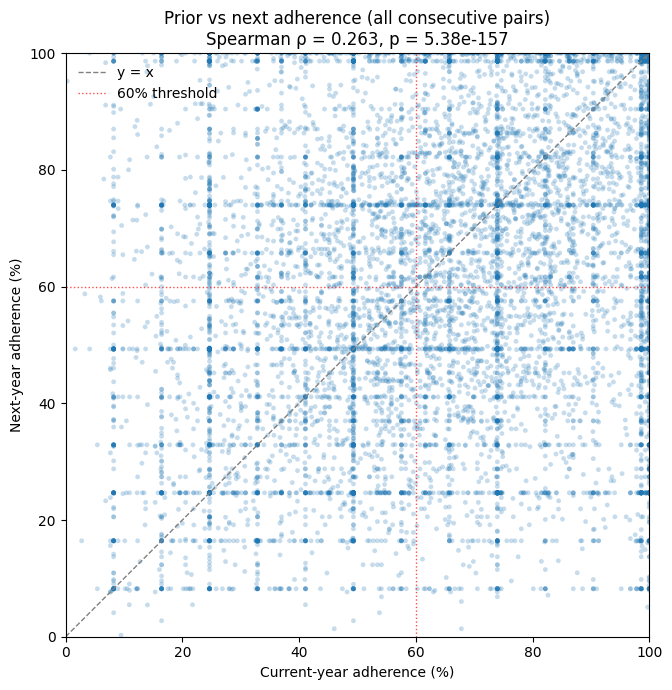

,N pairs,Spearman ρ,p-value,Significant (p<0.05),Mean current-year adherence,Mean next-year adherence
0,9919,0.2633,5.378431e-157,True,64.1,61.6


In [45]:
# Prior-year vs next-year adherence: scatter + Spearman correlation
import matplotlib.pyplot as plt
from scipy import stats

adh_pairs = year_pairs[
    ["meps_adherence_ratio_prev", "meps_adherence_ratio_next", "YEAR_prev", "YEAR_next"]
].dropna().copy()
adh_pairs = adh_pairs.rename(
    columns={
        "meps_adherence_ratio_prev": "Adherence current year",
        "meps_adherence_ratio_next": "Adherence next year",
    }
)

rho, p_spearman = stats.spearmanr(
    adh_pairs["Adherence current year"],
    adh_pairs["Adherence next year"],
)

print(
    f"Consecutive person-year pairs: {len(adh_pairs):,}\n"
    f"Spearman ρ = {rho:.4f}  |  p = {p_spearman:.4g}  |  "
    f"{'significant' if p_spearman < 0.05 else 'not significant'} (α=0.05)"
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    adh_pairs["Adherence current year"],
    adh_pairs["Adherence next year"],
    s=12,
    alpha=0.25,
    edgecolors="none",
)
ax.plot([0, 100], [0, 100], linestyle="--", linewidth=1, color="gray", label="y = x")
ax.axvline(60, color="red", linestyle=":", linewidth=1, alpha=0.7)
ax.axhline(60, color="red", linestyle=":", linewidth=1, alpha=0.7, label="60% threshold")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel("Current-year adherence (%)")
ax.set_ylabel("Next-year adherence (%)")
ax.set_title(
    f"Prior vs next adherence (all consecutive pairs)\n"
    f"Spearman ρ = {rho:.3f}, p = {p_spearman:.2e}"
)
ax.legend(loc="upper left", frameon=False)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

spearman_summary = pd.DataFrame(
    [
        {
            "N pairs": len(adh_pairs),
            "Spearman ρ": round(rho, 4),
            "p-value": p_spearman,
            "Significant (p<0.05)": p_spearman < 0.05,
            "Mean current-year adherence": round(
                adh_pairs["Adherence current year"].mean(), 1
            ),
            "Mean next-year adherence": round(
                adh_pairs["Adherence next year"].mean(), 1
            ),
        }
    ]
)
display(spearman_summary)


In [ ]:
# Adherence bins of 10 + jump sizes + major multi-year fluctuators
BIN_EDGES = list(range(0, 110, 10))  # 0–10, …, 90–100
BIN_LABELS = [f"{lo}–{hi}" for lo, hi in zip(BIN_EDGES[:-1], BIN_EDGES[1:])]

adh_bin = year_pairs[
    ["DUPERSID", "YEAR_prev", "YEAR_next", "meps_adherence_ratio_prev", "meps_adherence_ratio_next"]
].dropna().copy()

# Floor into 10pp bins; put exact 100 into 90–100
adh_bin["bin_current"] = pd.cut(
    adh_bin["meps_adherence_ratio_prev"].clip(upper=99.999),
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
)
adh_bin["bin_next"] = pd.cut(
    adh_bin["meps_adherence_ratio_next"].clip(upper=99.999),
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
)
adh_bin["adh_delta"] = (
    adh_bin["meps_adherence_ratio_next"] - adh_bin["meps_adherence_ratio_prev"]
)
adh_bin["abs_jump"] = adh_bin["adh_delta"].abs()
adh_bin["jump_size"] = pd.cut(
    adh_bin["abs_jump"],
    bins=[-0.001, 10, 20, 30, np.inf],
    labels=["≤10 pp", "10–20 pp", "20–30 pp", ">30 pp"],
)
adh_bin["jump_direction"] = np.select(
    [adh_bin["adh_delta"] > 0, adh_bin["adh_delta"] < 0, adh_bin["adh_delta"] == 0],
    ["Up", "Down", "No change"],
    default="Unknown",
)

# --- 1) Transition counts: current bin → next bin ---
transition_counts = (
    adh_bin.groupby(["bin_current", "bin_next"], observed=False)
    .size()
    .unstack(fill_value=0)
)
print("Current-year bin → next-year bin (person-year pairs)")
display(transition_counts)

# --- 2) How many jumped 10 / 20 / 30 / >30 ---
jump_summary = (
    adh_bin.groupby(["jump_size", "jump_direction"], observed=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "Mean adherence before": ("meps_adherence_ratio_prev", "mean"),
            "Mean adherence after": ("meps_adherence_ratio_next", "mean"),
            "Change (pp)": ("adh_delta", "mean"),
            "Mean |Δ| (pp)": ("abs_jump", "mean"),
        }
    )
    .reset_index()
    .round(1)
)
print("\nJump size (absolute change) by direction")
display(jump_summary)

jump_overall = (
    adh_bin.groupby("jump_size", observed=False)
    .agg(
        **{
            "N (person-years)": ("DUPERSID", "size"),
            "N people": ("DUPERSID", "nunique"),
            "% of pairs": ("DUPERSID", lambda s: 100 * len(s) / len(adh_bin)),
        }
    )
    .reset_index()
    .round(1)
)
print("\nJump size overall")
display(jump_overall)

# --- 3) Major fluctuators: people with 3+ years and repeated large swings ---
# A "major swing" = consecutive-year |Δ| ≥ 20 pp
traj = (
    model_df[["DUPERSID", "YEAR", "meps_adherence_ratio"]]
    .dropna()
    .sort_values(["DUPERSID", "YEAR"])
    .copy()
)
traj["adh_bin"] = pd.cut(
    traj["meps_adherence_ratio"].clip(upper=99.999),
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
)
traj["adh_prev"] = traj.groupby("DUPERSID")["meps_adherence_ratio"].shift(1)
traj["year_prev"] = traj.groupby("DUPERSID")["YEAR"].shift(1)
consec = traj[traj["year_prev"] == traj["YEAR"] - 1].copy()
consec["abs_jump"] = (consec["meps_adherence_ratio"] - consec["adh_prev"]).abs()
consec["signed_jump"] = consec["meps_adherence_ratio"] - consec["adh_prev"]

MAJOR_SWING = 20  # pp
n_years = traj.groupby("DUPERSID")["YEAR"].nunique()
n_major_swings = (
    consec.loc[consec["abs_jump"] >= MAJOR_SWING]
    .groupby("DUPERSID")
    .size()
    .rename("n_major_swings")
)

# Direction pattern of major swings (e.g. up,up or up,down)
def _swing_pattern(g):
    signs = np.where(g["signed_jump"] >= MAJOR_SWING, "up", "down")
    return ",".join(signs)


swing_patterns = (
    consec.loc[consec["abs_jump"] >= MAJOR_SWING]
    .groupby("DUPERSID")
    .apply(_swing_pattern, include_groups=False)
    .rename("swing_pattern")
)

# Trajectory string like "20→60→30" using rounded adherence
def _traj_string(g):
    vals = g.sort_values("YEAR")["meps_adherence_ratio"].round(0).astype(int).astype(str)
    years = g.sort_values("YEAR")["YEAR"].astype(str)
    return " | ".join(f"{y}:{v}" for y, v in zip(years, vals))


def _bin_traj_string(g):
    bins = g.sort_values("YEAR")["adh_bin"].astype(str)
    years = g.sort_values("YEAR")["YEAR"].astype(str)
    return " | ".join(f"{y}:{b}" for y, b in zip(years, bins))


traj_stats = traj.groupby("DUPERSID").agg(
    n_years=("YEAR", "nunique"),
    first_year=("YEAR", "min"),
    last_year=("YEAR", "max"),
    mean_adh=("meps_adherence_ratio", "mean"),
    min_adh=("meps_adherence_ratio", "min"),
    max_adh=("meps_adherence_ratio", "max"),
)
traj_stats["range_pp"] = traj_stats["max_adh"] - traj_stats["min_adh"]
traj_stats = traj_stats.join(n_major_swings, how="left").fillna({"n_major_swings": 0})
traj_stats["n_major_swings"] = traj_stats["n_major_swings"].astype(int)
traj_stats = traj_stats.join(swing_patterns, how="left")

# Major fluctuators: ≥3 observed years AND ≥2 consecutive swings of ≥20 pp
fluctuators = traj_stats[
    (traj_stats["n_years"] >= 3) & (traj_stats["n_major_swings"] >= 2)
].copy()
fluctuators = fluctuators.sort_values(
    ["n_major_swings", "range_pp"], ascending=False
)

traj_strings = traj.groupby("DUPERSID").apply(_traj_string, include_groups=False)
bin_traj_strings = traj.groupby("DUPERSID").apply(_bin_traj_string, include_groups=False)
fluctuators["adherence_path"] = traj_strings
fluctuators["bin_path"] = bin_traj_strings

print(
    f"\nMajor fluctuators: ≥3 years and ≥2 consecutive swings of ≥{MAJOR_SWING} pp\n"
    f"N people = {len(fluctuators):,}"
)
fluctuator_summary = (
    fluctuators.groupby("swing_pattern", dropna=False)
    .agg(
        n_people=("n_major_swings", "size"),
        mean_range_pp=("range_pp", "mean"),
        mean_n_swings=("n_major_swings", "mean"),
    )
    .reset_index()
    .sort_values("n_people", ascending=False)
    .round(1)
)
print("Swing patterns (e.g. up,down = rose then fell by ≥20 pp)")
display(fluctuator_summary)

print("\nExample fluctuators (top 25 by # swings / range)")
display(
    fluctuators[
        [
            "n_years",
            "first_year",
            "last_year",
            "n_major_swings",
            "swing_pattern",
            "min_adh",
            "max_adh",
            "range_pp",
            "adherence_path",
            "bin_path",
        ]
    ]
    .head(25)
    .round(1)
)

# Optional save for follow-up
fluct_path = TABLES_DIR / "major_adherence_fluctuators.csv"
fluctuators.reset_index().to_csv(fluct_path, index=False)
print(f"\nWrote full fluctuator list → {fluct_path}")


Current-year bin → next-year bin (person-year pairs)


bin_next,0–10,10–20,20–30,30–40,40–50,50–60,60–70,70–80,80–90,90–100
bin_current,,,,,,,,,,
0–10,23,19,22,21,36,16,7,26,6,18
10–20,25,27,53,38,45,27,27,24,16,25
20–30,26,54,114,72,157,60,70,91,30,99
30–40,22,46,75,84,93,80,86,72,41,86
40–50,21,46,165,136,256,131,137,186,78,156
50–60,13,37,80,85,170,132,125,139,82,100
60–70,18,23,68,93,159,159,158,168,122,176
70–80,17,36,107,78,226,147,177,250,154,265
80–90,9,14,44,52,96,88,126,162,124,199



Jump size (absolute change) by direction


,jump_size,jump_direction,N (person-years),N people,Mean adherence before,Mean adherence after,Change (pp),Mean |Δ| (pp)
0,≤10 pp,Down,1293,1264,67.3,62.3,-5.0,5.0
1,≤10 pp,No change,503,494,72.3,72.3,0.0,0.0
2,≤10 pp,Up,1141,1122,62.0,66.9,4.9,4.9
3,10–20 pp,Down,1033,1022,69.6,54.6,-15.0,15.0
4,10–20 pp,No change,0,0,NaN,NaN,NaN,NaN
5,10–20 pp,Up,937,929,55.6,70.5,14.9,14.9
6,20–30 pp,Down,1023,1014,75.1,50.4,-24.8,24.8
7,20–30 pp,No change,0,0,NaN,NaN,NaN,NaN
8,20–30 pp,Up,871,867,49.6,74.4,24.8,24.8
9,>30 pp,Down,1745,1740,85.4,36.4,-49.0,49.0



Jump size overall


,jump_size,N (person-years),N people,% of pairs
0,≤10 pp,2937,2814,29.6
1,10–20 pp,1970,1910,19.9
2,20–30 pp,1894,1848,19.1
3,>30 pp,3118,2974,31.4


In [48]:
# Trajectory classes: increasing / decreasing / recovering / relapsing / stable
BIN_EDGES = list(range(0, 110, 10))
BIN_LABELS = [f"{lo}–{hi}" for lo, hi in zip(BIN_EDGES[:-1], BIN_EDGES[1:])]


def _compress_signs(deltas, eps=1e-9):
    """Drop near-zero changes; keep order of up/down moves as '+'/'-'."""
    out = []
    for d in deltas:
        if d > eps:
            out.append("+")
        elif d < -eps:
            out.append("-")
    return "".join(out)


def classify_trajectory(adh_values):
    """
    Classify one person's ordered adherence series.
      stable     – all years in the same 10 pp bin
      increasing – every consecutive change ≥ 0, and at least one rise
      decreasing – every consecutive change ≤ 0, and at least one fall
      recovering – went down, then up again (ends with an up after a down)
      relapsing  – down→up→down (or up→down after having risen)
    """
    adh = list(adh_values)
    if len(adh) < 2:
        return "insufficient_years"

    bins = pd.cut(
        pd.Series(adh).clip(upper=99.999),
        bins=BIN_EDGES,
        labels=BIN_LABELS,
        right=False,
    )
    if bins.nunique(dropna=False) == 1:
        return "stable"

    deltas = [adh[i + 1] - adh[i] for i in range(len(adh) - 1)]
    signs = _compress_signs(deltas)

    if not signs:
        return "stable"
    if set(signs) == {"+"}:
        return "increasing"
    if set(signs) == {"-"}:
        return "decreasing"

    # Relapsing: down, up, down  OR  rose then fell (up, down…)
    if "-+-" in signs or signs.startswith("+-") or signs.endswith("+-"):
        # pure +- / -+- / +-+- etc. that include a relapse after improvement
        if "-+-" in signs or signs.startswith("+-"):
            return "relapsing"
        # +-+ ends with recovery → recovering below

    # Recovering: went down, then up again (has - followed later by +)
    if "-" in signs and "+" in signs:
        first_down = signs.find("-")
        later_up = signs.find("+", first_down + 1)
        if later_up != -1:
            # If after that recovery there is another down → relapsing
            if signs.find("-", later_up + 1) != -1:
                return "relapsing"
            return "recovering"
        # up then down only (no down-before-up) → relapsing
        if signs.find("+") < signs.find("-"):
            return "relapsing"

    return "other"


traj = (
    model_df[["DUPERSID", "YEAR", "meps_adherence_ratio"]]
    .dropna()
    .sort_values(["DUPERSID", "YEAR"])
    .copy()
)
traj["adh_bin"] = pd.cut(
    traj["meps_adherence_ratio"].clip(upper=99.999),
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
)

# Prefer consecutive calendar years only when building each person's path
def _person_class(g):
    g = g.sort_values("YEAR")
    years = g["YEAR"].to_numpy()
    adh = g["meps_adherence_ratio"].to_numpy()

    empty = {
        "trajectory_class": "insufficient_years",
        "n_years": 0,
        "first_year": pd.NA,
        "last_year": pd.NA,
        "adh_first": pd.NA,
        "adh_last": pd.NA,
        "adh_min": pd.NA,
        "adh_max": pd.NA,
        "adherence_path": "",
        "bin_path": "",
        "sign_pattern": "",
    }

    if len(years) < 1:
        return empty
    if len(years) < 2:
        return {
            **empty,
            "n_years": 1,
            "first_year": int(years[0]),
            "last_year": int(years[0]),
            "adh_first": float(adh[0]),
            "adh_last": float(adh[0]),
            "adh_min": float(adh[0]),
            "adh_max": float(adh[0]),
            "adherence_path": f"{int(years[0])}:{adh[0]:.0f}",
            "bin_path": "",
            "sign_pattern": "",
        }

    # split into consecutive segments; use the longest
    segments = []
    start = 0
    for i in range(1, len(years)):
        if years[i] != years[i - 1] + 1:
            segments.append((start, i))
            start = i
    segments.append((start, len(years)))
    a, b = max(segments, key=lambda ab: ab[1] - ab[0])
    years_s, adh_s = years[a:b], adh[a:b]

    if len(years_s) < 2:
        return {
            **empty,
            "n_years": 1,
            "first_year": int(years_s[0]),
            "last_year": int(years_s[0]),
            "adh_first": float(adh_s[0]),
            "adh_last": float(adh_s[0]),
            "adh_min": float(adh_s[0]),
            "adh_max": float(adh_s[0]),
            "adherence_path": f"{int(years_s[0])}:{adh_s[0]:.0f}",
        }

    bins_s = (
        pd.cut(
            pd.Series(adh_s).clip(upper=99.999),
            bins=BIN_EDGES,
            labels=BIN_LABELS,
            right=False,
        )
        .astype(str)
        .tolist()
    )
    deltas = [adh_s[i + 1] - adh_s[i] for i in range(len(adh_s) - 1)]
    path = " → ".join(f"{int(y)}:{v:.0f}" for y, v in zip(years_s, adh_s))
    bin_path = " → ".join(f"{int(y)}:{bb}" for y, bb in zip(years_s, bins_s))
    return {
        "trajectory_class": classify_trajectory(adh_s),
        "n_years": int(len(years_s)),
        "first_year": int(years_s[0]),
        "last_year": int(years_s[-1]),
        "adh_first": float(adh_s[0]),
        "adh_last": float(adh_s[-1]),
        "adh_min": float(adh_s.min()),
        "adh_max": float(adh_s.max()),
        "adherence_path": path,
        "bin_path": bin_path,
        "sign_pattern": _compress_signs(deltas),
    }


# Build as a plain DataFrame (avoids groupby.apply column-shape issues)
person_rows = []
for dupersid, g in traj.groupby("DUPERSID", sort=False):
    row = _person_class(g)
    row["DUPERSID"] = dupersid
    person_rows.append(row)
person_traj = pd.DataFrame(person_rows)

class_order = [
    "increasing",
    "decreasing",
    "recovering",
    "relapsing",
    "stable",
    "other",
    "insufficient_years",
]
class_counts = (
    person_traj["trajectory_class"]
    .value_counts()
    .reindex(class_order)
    .dropna()
    .rename("N people")
    .to_frame()
)
class_counts["% of people"] = (
    100 * class_counts["N people"] / class_counts["N people"].sum()
).round(1)

print("Trajectory class definitions")
print(
    "  stable     – same 10 pp bin every year\n"
    "  increasing – adherence only rises (or flat+rise)\n"
    "  decreasing – adherence only falls (or flat+fall)\n"
    "  recovering – went down, then up again\n"
    "  relapsing  – down→up→down, or up→down after improvement"
)
display(class_counts)

class_detail = (
    person_traj.groupby("trajectory_class", observed=False)
    .agg(
        **{
            "N people": ("DUPERSID", "size"),
            "Mean years observed": ("n_years", "mean"),
            "Mean first adherence": ("adh_first", "mean"),
            "Mean last adherence": ("adh_last", "mean"),
            "Mean min": ("adh_min", "mean"),
            "Mean max": ("adh_max", "mean"),
        }
    )
    .reindex(class_order)
    .dropna(how="all")
    .round(1)
)
print("\nSummary by class")
display(class_detail)

print("\nExamples per class")
for cls in ["increasing", "decreasing", "recovering", "relapsing", "stable"]:
    ex = person_traj.loc[person_traj["trajectory_class"] == cls].head(5)
    if ex.empty:
        continue
    print(f"\n{cls} (showing up to 5)")
    display(
        ex[
            [
                "DUPERSID",
                "n_years",
                "sign_pattern",
                "adherence_path",
                "bin_path",
            ]
        ]
    )

out_path = TABLES_DIR / "adherence_trajectory_classes.csv"
person_traj.to_csv(out_path, index=False)
print(f"\nWrote {len(person_traj):,} people → {out_path}")


KeyError: 'trajectory_class'